# Detección temprana de PDAC mediante modelos de Machine Learning a partir de Biomarcadores Urinarios

Miriam Romero Bautista, Ingeniería de la Salud US

El PDAC es uno de los cánceres con peor pronóstico debido a su diagnóstico tardío y a la ausencia de síntomas en fases iniciales. En este contexto la identificación de estrategias para una detección temprana constituye uno de los principales retos clínicos actuales, ya que los estadios iniciales son los más susceptibles a tratamiento curativo.

El objetivo principal del presente trabajo es evaluar la capacidad de diferentes biomarcadores para discriminar entre pacientes con PDAC en estadios iniciales y controles sanos, mediante la aplicación de modelos de Machine Learning a un conjunto de datos. Consideramos como estadios inciales los que abarcan del I-II siguiendo la clasificación TNM, que incluyen tumores sin metástasis ni invasión a estructuras locales, que incluye aquellos pacientes en los que es posible la intervención quirúrgica curativa.

In [1]:
!pip install /kaggle/input/datasets/miroba15/plotly-pack/plotly-6.7.0-py3-none-any.whl

Processing /kaggle/input/datasets/miroba15/plotly-pack/plotly-6.7.0-py3-none-any.whl
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


In [2]:
!pip install /kaggle/input/datasets/miroba15/dalex/dalex-1.8.0-py3-none-any.whl


Processing /kaggle/input/datasets/miroba15/dalex/dalex-1.8.0-py3-none-any.whl


In [3]:
import copy
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import gaussian_kde

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, adjusted_rand_score, average_precision_score,
    balanced_accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
    roc_auc_score, silhouette_score
)
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

from xgboost import XGBClassifier

from IPython.display import display
import dalex as dx
import shap

SEED = 42
np.random.seed(SEED)

## 1. COMPRENDER Y ANALIZAR DATASET

In [4]:
#Descripción de variables del dataset
documentation = pd.read_csv("/kaggle/input/datasets/johnjdavisiv/urinary-biomarkers-for-pancreatic-cancer/Debernardi et al 2020 documentation.csv")
documentation

,Column name,Original column name,Details
0,sample_id,Sample ID,Unique string identifying each subject
1,patient_cohort,Patient's Cohort,"Cohort 1, previously used samples; Cohort 2, ..."
2,sample_origin,Sample Origin,"BPTB: Barts Pancreas Tissue Bank, London, UK; ..."
3,age,Age,Age in years
4,sex,Sex,"M = male, F = female"
5,diagnosis,"Diagnosis (1=Control, 2=Benign, 3=PDAC)","1 = control (no pancreatic disease), 2 = benig..."
6,stage,Stage,"For those with pancratic cancer, what stage wa..."
7,benign_sample_diagnosis,Benign Samples Diagnosis,"For those with a benign, non-cancerous diagnos..."
8,plasma_CA19_9,Plasma CA19-9 U/ml,Blood plasma levels of CA 19–9 monoclonal anti...
9,creatinine,Creatinine mg/ml,Urinary biomarker of kidney function


In [5]:
#Dataset completo
datos = pd.read_csv("/kaggle/input/datasets/johnjdavisiv/urinary-biomarkers-for-pancreatic-cancer/Debernardi et al 2020 data.csv")
datos

,sample_id,patient_cohort,sample_origin,age,sex,diagnosis,stage,benign_sample_diagnosis,plasma_CA19_9,creatinine,LYVE1,REG1B,TFF1,REG1A
0,S1,Cohort1,BPTB,33,F,1,NaN,NaN,11.7,1.83222,0.893219,52.948840,654.282174,1262.000
1,S10,Cohort1,BPTB,81,F,1,NaN,NaN,NaN,0.97266,2.037585,94.467030,209.488250,228.407
2,S100,Cohort2,BPTB,51,M,1,NaN,NaN,7.0,0.78039,0.145589,102.366000,461.141000,NaN
3,S101,Cohort2,BPTB,61,M,1,NaN,NaN,8.0,0.70122,0.002805,60.579000,142.950000,NaN
4,S102,Cohort2,BPTB,62,M,1,NaN,NaN,9.0,0.21489,0.000860,65.540000,41.088000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585,S549,Cohort2,BPTB,68,M,3,IV,NaN,NaN,0.52026,7.058209,156.241000,525.178000,NaN
586,S558,Cohort2,BPTB,71,F,3,IV,NaN,NaN,0.85956,8.341207,16.915000,245.947000,NaN
587,S560,Cohort2,BPTB,63,M,3,IV,NaN,NaN,1.36851,7.674707,289.701000,537.286000,NaN
588,S583,Cohort2,BPTB,75,F,3,IV,NaN,NaN,1.33458,8.206777,205.930000,722.523000,NaN


In [6]:
#Dimensiones: 590 filas y 14 columnas/variables
datos.shape

(590, 14)

In [7]:
#variables
columnas = datos.columns
columnas

Index(['sample_id', 'patient_cohort', 'sample_origin', 'age', 'sex',
       'diagnosis', 'stage', 'benign_sample_diagnosis', 'plasma_CA19_9',
       'creatinine', 'LYVE1', 'REG1B', 'TFF1', 'REG1A'],
      dtype='object')

In [8]:
#Número de pacientes según diagnóstico: (1=Control, 2=Benigno, 3=PDAC)	
datos["diagnosis"].value_counts()

diagnosis
2    208
3    199
1    183
Name: count, dtype: int64

In [9]:
#Número de pacientes con PDAC por estadio
pd.crosstab(datos["stage"], datos["diagnosis"])

diagnosis,3
stage,
I,1
IA,3
IB,12
II,7
IIA,11
IIB,68
III,76
IV,21


El dataset incluye 14 variables y 590 muestras de orina de pacientes procedentes de diversos centros. Encontramos datos de 183 controles sanos, 208 pacientes con enfermedades benignas y 199 pacientes con PDAC (102 en estadios tempranos I–II Y 97 en estadios avanzados). El hecho de que el estadio III sea el más frecuente (76 pacientes) y que el estadios I solo sumen 16 pacientes refleja el problema clínico que motiva este proyecto: el PDAC se diagnostica tarde en la mayoría de casos. Dado que nuestro objetivo es discriminar pacientes con PDAC en estadios tempranos, excluiremos aquellos pacientes en estadios III-IV dado que los datos de estos podrían inflar artificialmente las métricas.

In [10]:
pdac_iniciales = (datos["diagnosis"] == 3) & (datos["stage"].isin(["I", "IA", "IB", "II", "IIA", "IIB"])) #pacientes con PDAC y estadios del I-II

no_pdac = datos["diagnosis"].isin([1, 2]) #controles sanos y patologías benignas

datos = datos[pdac_iniciales | no_pdac]

In [11]:
#dimensiones del nuevo conjunto de datos
datos.shape

(493, 14)

In [12]:
#Número de pacientes según diagnóstico
datos["diagnosis"].value_counts()

diagnosis
2    208
1    183
3    102
Name: count, dtype: int64

## 2. PREPROCESAMIENTO Y LIMPIEZA DE DATOS

En este apartado nos enfocaremos en la detección de valores nulos y su tratamiento, en la identificación de la distribución de los valores, el estudio de las correlaciones y posibles redundancias de variables, y valores extremos (outliers) que puedan distorsionar el entrenamiento.

Para comenzar, es necesario tener en cuenta que la orina es muy variable debido a la hidratación del individuo. Esta variabilidad puede provocar que la concentración de biomarcadores aparezca aumentada en orina concentrada o disminuida en orina diluida, sin reflejar cambios reales. Para reducir este efecto se utiliza habitualmente la creatinina como factor de normalización, ya que su excreción es relativamente estable en condiciones fisiológicas. Aunque no es completamente constante, permite corregir las diferencias de dilución entre muestras. 

In [13]:
#Normalización de valores mediante creatinina
biomarcadores = ["LYVE1", "REG1B", "TFF1", "REG1A"]
for i in biomarcadores: datos[i + "_normalizado"] = datos[i] / datos["creatinine"]
datos

,sample_id,patient_cohort,sample_origin,age,sex,diagnosis,stage,benign_sample_diagnosis,plasma_CA19_9,creatinine,LYVE1,REG1B,TFF1,REG1A,LYVE1_normalizado,REG1B_normalizado,TFF1_normalizado,REG1A_normalizado
0,S1,Cohort1,BPTB,33,F,1,NaN,NaN,11.7,1.83222,0.893219,52.94884,654.282174,1262.000,0.487507,28.898735,357.098042,688.781915
1,S10,Cohort1,BPTB,81,F,1,NaN,NaN,NaN,0.97266,2.037585,94.46703,209.488250,228.407,2.094858,97.122355,215.376648,234.827175
2,S100,Cohort2,BPTB,51,M,1,NaN,NaN,7.0,0.78039,0.145589,102.36600,461.141000,NaN,0.186559,131.172875,590.910955,NaN
3,S101,Cohort2,BPTB,61,M,1,NaN,NaN,8.0,0.70122,0.002805,60.57900,142.950000,NaN,0.004000,86.390862,203.858989,NaN
4,S102,Cohort2,BPTB,62,M,1,NaN,NaN,9.0,0.21489,0.000860,65.54000,41.088000,NaN,0.004000,304.993252,191.204802,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488,S578,Cohort2,BPTB,57,M,3,IIB,NaN,NaN,0.48633,2.828798,208.37100,333.852000,NaN,5.816622,428.455987,686.472149,NaN
489,S579,Cohort2,BPTB,82,M,3,IIB,NaN,NaN,0.46371,6.011376,150.05600,263.163000,NaN,12.963654,323.598801,567.516336,NaN
490,S580,Cohort2,BPTB,88,F,3,IIB,NaN,NaN,1.09707,10.273040,113.09400,1256.712000,NaN,9.364070,103.087314,1145.516694,NaN
491,S581,Cohort2,BPTB,67,F,3,IIB,NaN,NaN,0.32799,1.172141,123.27000,43.537000,NaN,3.573710,375.834629,132.738803,NaN


In [14]:
#Codificamos el campo sexo para facilitar el tratamiento de la variable
datos["sex"] = LabelEncoder().fit_transform(datos["sex"]) #0=male;  1=female
datos

,sample_id,patient_cohort,sample_origin,age,sex,diagnosis,stage,benign_sample_diagnosis,plasma_CA19_9,creatinine,LYVE1,REG1B,TFF1,REG1A,LYVE1_normalizado,REG1B_normalizado,TFF1_normalizado,REG1A_normalizado
0,S1,Cohort1,BPTB,33,0,1,NaN,NaN,11.7,1.83222,0.893219,52.94884,654.282174,1262.000,0.487507,28.898735,357.098042,688.781915
1,S10,Cohort1,BPTB,81,0,1,NaN,NaN,NaN,0.97266,2.037585,94.46703,209.488250,228.407,2.094858,97.122355,215.376648,234.827175
2,S100,Cohort2,BPTB,51,1,1,NaN,NaN,7.0,0.78039,0.145589,102.36600,461.141000,NaN,0.186559,131.172875,590.910955,NaN
3,S101,Cohort2,BPTB,61,1,1,NaN,NaN,8.0,0.70122,0.002805,60.57900,142.950000,NaN,0.004000,86.390862,203.858989,NaN
4,S102,Cohort2,BPTB,62,1,1,NaN,NaN,9.0,0.21489,0.000860,65.54000,41.088000,NaN,0.004000,304.993252,191.204802,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488,S578,Cohort2,BPTB,57,1,3,IIB,NaN,NaN,0.48633,2.828798,208.37100,333.852000,NaN,5.816622,428.455987,686.472149,NaN
489,S579,Cohort2,BPTB,82,1,3,IIB,NaN,NaN,0.46371,6.011376,150.05600,263.163000,NaN,12.963654,323.598801,567.516336,NaN
490,S580,Cohort2,BPTB,88,0,3,IIB,NaN,NaN,1.09707,10.273040,113.09400,1256.712000,NaN,9.364070,103.087314,1145.516694,NaN
491,S581,Cohort2,BPTB,67,0,3,IIB,NaN,NaN,0.32799,1.172141,123.27000,43.537000,NaN,3.573710,375.834629,132.738803,NaN


In [15]:
#Número de pacientes con distintas diagnósticos según cohorte
pd.crosstab(datos["patient_cohort"], datos["diagnosis"])

diagnosis,1,2,3
patient_cohort,,,
Cohort1,81,89,74
Cohort2,102,119,28


Vamos a eliminar aquellas columnas que no sean relevantes para el entrenamiento de datos para evitar ruido, como son el sample_id (identificador del registro), sample_origin (se podría realizar el estudio según la localización de origen) y patient_cohort (hay más pacientes con PDAC en el cohorte1, por lo que el hecho de que una muestra venga de dicho grupo aumenta las probabilidades de que se le asocie con tener PDAC y puede provocar confusiones en el modelo). Eliminaremos también las columnas benign_sample_diagnosis y stage dado que son consecuecias del diagnóstico, nuestro objetivo es la detección temprana a partir de biomarcadores dando como resultado paciente positivo o negativo en PDAC, como solución a futuro se podría determinar el estadio en caso de que el diagnóstico sea positivo o la enfermedad benigna que presenta el paciente en caso de ser negativo.

In [16]:
datos.drop(columns=["sample_id", "sample_origin", "patient_cohort", "benign_sample_diagnosis", "stage", "creatinine", "LYVE1", "REG1B", "TFF1", "REG1A"], inplace=True)
datos

,age,sex,diagnosis,plasma_CA19_9,LYVE1_normalizado,REG1B_normalizado,TFF1_normalizado,REG1A_normalizado
0,33,0,1,11.7,0.487507,28.898735,357.098042,688.781915
1,81,0,1,NaN,2.094858,97.122355,215.376648,234.827175
2,51,1,1,7.0,0.186559,131.172875,590.910955,NaN
3,61,1,1,8.0,0.004000,86.390862,203.858989,NaN
4,62,1,1,9.0,0.004000,304.993252,191.204802,NaN
...,...,...,...,...,...,...,...,...
488,57,1,3,NaN,5.816622,428.455987,686.472149,NaN
489,82,1,3,NaN,12.963654,323.598801,567.516336,NaN
490,88,0,3,NaN,9.364070,103.087314,1145.516694,NaN
491,67,0,3,NaN,3.573710,375.834629,132.738803,NaN


In [17]:
#Copia de datos para el entrenamiento:
datos_ml = datos.copy()

Ante la presencia de valores nulos o ausentes, eliminaremos las variables o sustituiremos los valores nulos mediante la imputación de la mediana. Elegimos la mediana porque se trata del valor central del conjunto de muestras, lo que representa mejor al paciente típico del grupo.

In [18]:
#Obtenemos información sobre los valores nulos del dataset
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 493 entries, 0 to 492
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                493 non-null    int64  
 1   sex                493 non-null    int64  
 2   diagnosis          493 non-null    int64  
 3   plasma_CA19_9      280 non-null    float64
 4   LYVE1_normalizado  493 non-null    float64
 5   REG1B_normalizado  493 non-null    float64
 6   TFF1_normalizado   493 non-null    float64
 7   REG1A_normalizado  236 non-null    float64
dtypes: float64(5), int64(3)
memory usage: 34.7 KB


In [19]:
#Porcentaje de valores nulos
datos.isnull().sum()
(datos.isnull().mean()*100).round(3)

age                   0.000
sex                   0.000
diagnosis             0.000
plasma_CA19_9        43.205
LYVE1_normalizado     0.000
REG1B_normalizado     0.000
TFF1_normalizado      0.000
REG1A_normalizado    52.130
dtype: float64

Las columnas plasma_CA19_9 y REG1A presentan un elevado porcentaje de valores ausentes pero dado su interés clínico, las conservamos aplicando imputación mediante mediana para mantener la estabilidad del análisis.                     

In [20]:
datos['plasma_CA19_9'].fillna(np.nanmedian(datos['plasma_CA19_9']), inplace=True)
datos['REG1A_normalizado'].fillna(np.nanmedian(datos['REG1A_normalizado']), inplace=True)

In [21]:
#Porcentaje de valores nulos tras la imputación
datos.isnull().sum()
(datos.isnull().mean()*100).round(3)

age                  0.0
sex                  0.0
diagnosis            0.0
plasma_CA19_9        0.0
LYVE1_normalizado    0.0
REG1B_normalizado    0.0
TFF1_normalizado     0.0
REG1A_normalizado    0.0
dtype: float64

La variable "sex" aporta información demográfica pero no aporta información relevante en nuestro estudio sobre biomarcadores, es por ello que la mantendremos en el dataset pero no la incluiremos en los análisis previos al entrenamiento de modelos.

In [22]:
#Número de pacientes con distintas diagnósticos según sexo
pd.crosstab(datos["sex"], datos["diagnosis"])

diagnosis,1,2,3
sex,,,
0,115,101,49
1,68,107,53


## 3. ANÁLISIS DE LA CAPACIDAD DIAGNÓSTICA DE BIOMARCADORES INDIVIDUALMENTE

A continuación, evaluaremos si existe algún biomarcador que de manera individual pueda determinar si el paciente presenta PDAC en etapas tempranas o si sería conveniente la creación de un modelo de diágnositco que los combine.

### 3.1 EVALUACIÓN ESTADÍSTICA

In [23]:
biomarcadores = ["age", "plasma_CA19_9", "LYVE1_normalizado", "REG1B_normalizado", "TFF1_normalizado", "REG1A_normalizado"]

In [24]:
#Análisis estadístico de datos globales de tipo numérico
#Count:número pacientes por grupos
#Mean: media aritmética, sensible a valores extremos por lo que no se usa como valor representativo del grupo
#Median: valor medio de la distribución, el 50% pacientes está por debajo y el otro por encima. Se considera como representativo del paciente "típico" del grupo.
#std: dispersión de los valores alrededor de la media. Si hay un valor elevado de dispersión, el comportamiento del biomarcador se considera diverso dentro de un mismo grupo y puede no ser útil para todos los pcientes.
#Min/Max: valores extremos del conjunto.
#25%/75% (percentiles): el 25% de pacientes está por debajo del P25 y el 75% por debajo del P75. La diferencia entre estos se llama rango intercuartílico (IQR), si el IQR es pequeño pero el max es alto implica que la mayoría de pacientes tiene valores similares pero hay algunos valores extremos.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

datos.groupby("diagnosis").describe().round(3).T

diagnosis                       1         2          3
age               count   183.000   208.000    102.000
                  mean     56.333    54.702     67.196
                  std      12.203    13.343      9.253
                  min      26.000    26.000     44.000
                  25%      48.500    44.000     61.000
                  50%      57.000    54.000     68.000
                  75%      63.000    66.000     74.000
                  max      89.000    82.000     88.000
sex               count   183.000   208.000    102.000
                  mean      0.372     0.514      0.520
                  std       0.485     0.501      0.502
                  min       0.000     0.000      0.000
                  25%       0.000     0.000      0.000
                  50%       0.000     1.000      1.000
                  75%       1.000     1.000      1.000
                  max       1.000     1.000      1.000
plasma_CA19_9     count   183.000   208.000    102.000
                  mean     12.504    39.918    946.738
                  std       9.414   171.067   3352.147
                  min       0.000     1.000      0.600
                  25%       5.335    16.150     16.300
                  50%      16.300    16.300    140.500
                  75%      16.300    17.250    550.000
                  max      84.300  1913.000  31000.000
LYVE1_normalizado count   183.000   208.000    102.000
                  mean      1.303     3.211     10.024
                  std       2.056     5.689      9.586
                  min       0.000     0.004      0.004
                  25%       0.004     0.279      3.428
                  50%       0.227     1.516      7.344
                  75%       1.737     3.872     13.201
                  max      11.611    49.938     57.374
REG1B_normalizado count   183.000   208.000    102.000
                  mean     58.500   106.610    390.823
                  std      88.599   233.741    540.233
                  min       0.002     0.002      4.448
                  25%      14.218    10.872     72.727
                  50%      28.899    34.595    224.903
                  75%      70.231    90.823    469.671
                  max     670.327  2196.516   3822.716
TFF1_normalizado  count   183.000   208.000    102.000
                  mean    171.480   575.388   1869.684
                  std     226.814   824.795   2851.024
                  min       0.078     0.078      0.078
                  25%      17.279   110.102    411.043
                  50%     102.145   312.340   1050.728
                  75%     239.471   655.683   2236.158
                  max    1522.554  4772.396  23597.558
REG1A_normalizado count   183.000   208.000    102.000
                  mean    215.499   391.292   1256.540
                  std     223.745   795.347   2346.875
                  min       0.000     0.000     33.141
                  25%     169.114   186.047    192.475
                  50%     192.475   192.475    294.765
                  75%     192.475   192.475   1427.769
                  max    2507.837  5745.826  15713.023

Comparando los resultados estadísticos entre los 3 grupos de diagnóstico vemos que:

- La edad no muestra diferencias significativas entre los grupos, aunque los pacientes con PDAC son ligeramente mayores (68 años frente a 57 en Control y 54 en Benigno), lo que coincide con la epidemiología de la enfermedad.
  
- La mediana del plasma_CA19_9 del grupo PDAC (50%=140.5 U/mL) es aproximadamente 9 veces mayor a la de Control (50%=16.3 U/mL) y Benigno (50%=16.3 U/mL). Sin embargo, su desviación típica en PDAC es de 3.352 U/mL, lo que indica que hay pacientes PDAC con valores bajos, limitando su utilidad como marcador único.

- El LYVE1_normalizado presenta un gradiente progresivo de medianas de 0.23 ng/mg, 1.52 ng/mg y 7.34 ng/mg para Control, Benigno y PDAC respectivamente, lo que lo convierte en el biomarcador urinario con mayor poder discriminatorio del panel.

- El REG1B_normalizado presenta una alta variabilidad en PDAC (std=540 ng/mg), aunque su mediana en PDAC (224.9 ng/mg) es significativamente mayor respecto a Control (28.9 ng/mg) y Benigno (34.6 ng/mg). La similitud entre estos dos últimos grupos confirma que REG1B discrimina PDAC del resto pero no distingue condiciones benignas de controles sanos.

- El TFF1_normalizado es el biomarcador con mayor variabilidad (std=2851 ng/mg en PDAC, máximo=23.598 ng/mg). Su mediana en PDAC (1050.7 ng/mg) es aproximadamente 10 veces la de Control (102 ng/mg), pero su elevada dispersión lo hace más útil en combinación con otros marcadores que de forma aislada.

- El REG1A_normalizado presenta limitaciones importantes derivadas de la imputación por mediana aplicada al 48% de valores ausentes. El percentil 25 idéntico en Control y Benigno (192.475 ng/mg) y el percentil 75 idéntico en Control y Benigno (192.475 ng/mg) son artefactos directos de dicha imputación. Sus estadísticos deben interpretarse con cautela.

El análisis estadístico indica que ningún biomarcador individual es suficiente para discriminar PDAC de forma fiable. LYVE1 es el marcador más consistente con un gradiente progresivo entre grupos, mientras que plasma_CA19_9 presenta alta variabilidad en PDAC que limita su utilidad en estadios iniciales. REG1B y TFF1 presentan dispersión elevada, siendo más útiles en combinación. REG1A debe tratarse con cautela por su alto porcentaje de imputación.

### 3.2 EVALUACIÓN MEDIANTE HISTOGRAMAS DE DISTRIBUCIÓN

Utilizamos los histogramas para visualizar la distribución de las variables. Cada barra representerá un intervalo de valores y el número de pacientes en cada rango. Dada la variedad de valores que alcanzan los biomarcadores sería dificil representarlos en escala lineal y comparlos a posteriori, es por este motivo que usaremos la escala logaritmica --> log1p(x) (log(1 + x) = e^x - 1)

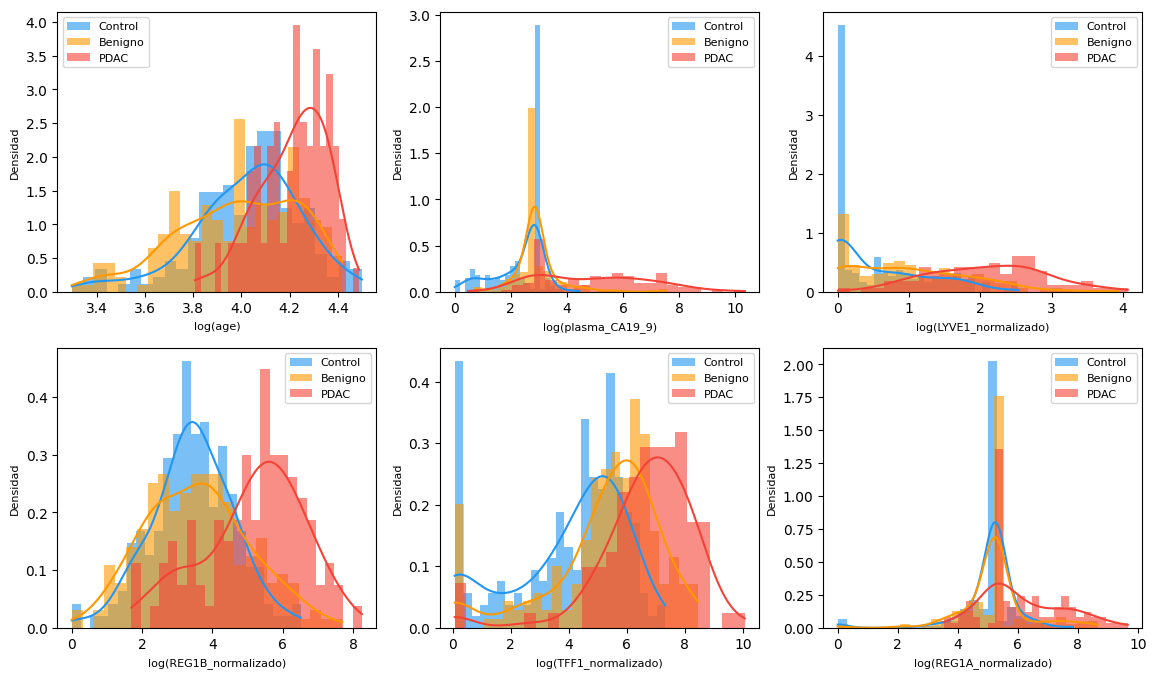

In [25]:
grupos = {1: ("Control","#2196F3"), 2: ("Benigno","#FF9800"), 3: ("PDAC","#F44336")}
 
fig, ejes = plt.subplots(2, 3, figsize=(14, 8)) #ajustar tamaño diagrama
for eje, columna in zip(ejes.flatten(), biomarcadores): #zip de lista con los 6 histogramas y 6 biomarcadores
    for diag, (nombre, color) in grupos.items(): #dibuja cada grupo en el histograma
        valores = datos[datos["diagnosis"] == diag][columna] #filtro del grupo
        
         #utilizamos log1p en vez de log porque hay valores de 0, solución: log1p(0) = log(1) = 0
        eje.hist(np.log1p(valores), bins=25, alpha=0.6, label=nombre,density=True, color=color)
        
        kde = gaussian_kde(np.log1p(valores)) #curva suavizada de la distribucion, coloca una campana gaussiana en cada punto
        x = np.linspace(np.log1p(valores).min(), np.log1p(valores).max(), 200) #le ponemos 200 uniformes entre el minimo y maximo del biomarcador
        eje.plot(x, kde(x), color=color, linewidth=1.5)
        
    eje.set_xlabel(f"log({columna})", fontsize=8)
    eje.set_ylabel("Densidad", fontsize=8) #Ante la diferencia de tamaño muestral (el número de pacientes varía según el diagnóstico): densidad = frecuencia / (total de pacientes × ancho de barra) 
#si en vez de densidad utilzamos frecuencias absolutas, el grupo benigno siempre va a tener barras más altas, dependiendo del número de pacientes del grupo
    eje.legend(fontsize=8)
 
plt.show()

En base a los histogramas observamos que:

- Los distintos grupos presentan una gran concentración en el rango log=3.4–4.4, equivalente a 30–88 años. Los grupos se encuentran prácticamente solapados, aunque el grupo PDAC muestra una distribución ligeramente desplazada hacia la derecha respecto a Control y Benigno, coherente con la mediana de 68 años observada en los estadísticos. Esto confirma que la edad no es un predictor relevante de forma aislada.

- Los tres grupos se concentran en valores bajos de plasma_CA19_9 en torno a log=3 (equivalente a 16.3 U/mL), que corresponde al valor de imputación de la mediana. El pico estrecho del grupo Benigno en ese valor es especialmente pronunciado, reflejo del alto porcentaje de imputación. El grupo PDAC muestra una cola derecha que se extiende hasta log=10 (22000 U/mL), prácticamente ausente en los otros grupos. Muchos pacientes con PDAC tienen niveles dentro del rango normal, especialmente en estadios iniciales, lo que refleja la limitación clínica del CA19-9 y la necesidad de biomarcadores urinarios complementarios.

- En el histograma de LYVE1_normalizado encontramos la mayor separación entre grupos. Control y Benigno presentan distribuciones concentradas en valores cercanos a 0, mientras que PDAC muestra una distribución más plana y desplazada hacia la derecha, con valores que se extienden hasta log=4 (54 ng/mg). Esta separación es más refuerza que LYVE1 es el biomarcador urinario con mayor poder discriminatorio individual del panel.

- Los tres grupos presentan distribuciones de REG1B_normalizado solapadas en valores bajos, pero el grupo PDAC muestra una cola derecha claramente más pronunciada que se extiende hasta log=8 (3000 ng/mg). Control y Benigno son prácticamente indistinguibles entre sí, lo que confirma que REG1B no distingue condiciones benignas de controles sanos pero sí aporta señal para detectar PDAC.

- Los tres grupos muestran distribuciones de TFF1_normalizado con un pico inicial en valores bajos (log=0–2, equivalente a 0–7 ng/mg) y una segunda concentración en valores medios-altos (log=4–7, equivalente a 54–1096 ng/mg). El grupo PDAC tiene su segunda concentración más desplazada hacia la derecha, alcanzando log=10 (22026 ng/mg). El solapamiento entre grupos es considerable, lo que confirma que TFF1 no es suficientemente específico de forma individual pero resulta útil en combinación con otros biomarcadores.

- Para el biomarcador REG1A_normalizado encontramos el spike artificial alrededor de log=5.5 (244 ng/mg) especialmente pronunciado en el grupo Benigno, consecuencia de la imputación por mediana aplicada al 48% de valores ausentes. 

Podemos concluir que los histogramas revelan que ningún biomarcador discrimina los tres grupos a la perfección. LYVE1 es el marcador con mayor separación visual, seguido de REG1B y TFF1.

### 3.3 EVALUACIÓN MEDIANTE DIAGRAMA DE CAJAS

Utilizaremos los diagramas de caja para obtener información sobre la variabilidad en el grupo de pacientes, los valores extremos y la simetría de la distribución. En estos diagramas podremos identidicar los siguientes elementos:

- Mediana: línea central de la caja que divide el 50% superior e inferior de los pacientes.
  
- Caja: se corresponde con el IQR, es decir, el 50% central de los datos, siendo e borde inferior el Q1 (p25) y el superior el Q3 (p75). A mayor tamaño, mayor variablidad entre pacientes, siendo una caja de menor tamaño un indicativo de homogeneidad entre las muestras.

- Bigotes: representa en rango de valores normales dentro del grupo, siendo los bigotes extremos inferior (Q1-1.5×IQR) y superior (Q3 + 1.5×IQR).

- Valores extremos (outerliers): aquellos valores extremos que no se condira habitual en el grupo.

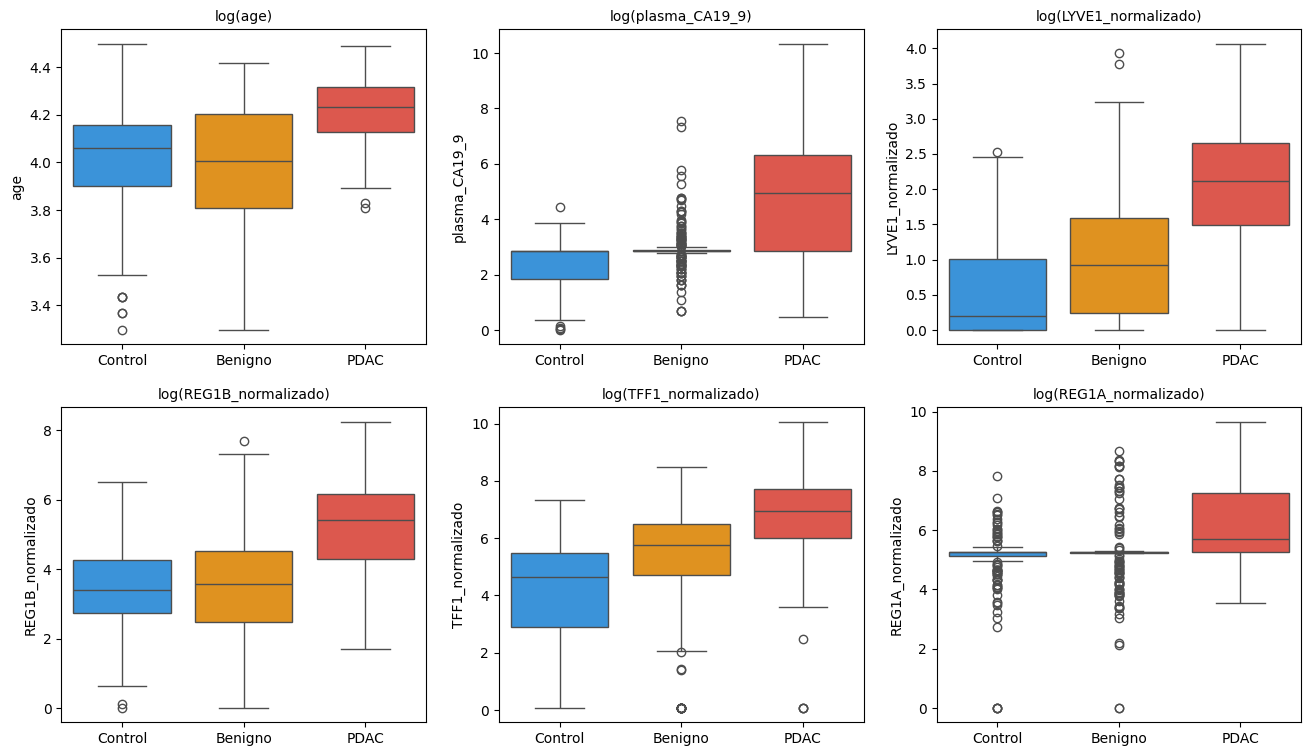

In [26]:
colores = {"Control": "#2196F3", "Benigno": "#FF9800", "PDAC": "#F44336"}
datos_box = datos.copy()
datos_box["grupo"] = datos_box["diagnosis"].map({1:"Control", 2:"Benigno", 3:"PDAC"})
 
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
 
for ax, col in zip(axes.flatten(), biomarcadores):
    tmp = datos_box[["grupo", col]].copy()
    tmp[col] = np.log1p(tmp[col])
    sns.boxplot(data=tmp, x="grupo", y=col, hue="grupo", palette=colores, legend=False, ax=ax)
    ax.set_title(f"log({col})", fontsize=10)
    ax.set_xlabel("") #para quitar el nombre de la variable del X
 
plt.show()

- Para la variable age, el grupo Benigno presenta la caja más amplia del panel (IQR=3.85–4.2), indicando mayor heterogeneidad de edad dentro de este grupo. Control y PDAC presentan cajas más compactas, aunque PDAC está desplazada hacia valores más altos con mediana en log=4.2 (66 años), frente a log=4.1 (60 años) en Control y log=4.0 (54 años) en Benigno, coherente con la epidemiología de la enfermedad. Los outliers inferiores en Control (log=3.3 y log=3.4, 27–30 años) corresponden a pacientes jóvenes atípicos sin repercusión relevante sobre la distribución general. El grupo PDAC presenta un outlier inferior aislado en log=3.8 (44 años).

- El grupo de pacientes con patologías benignas presenta una caja muy estrecha con mediana en log=3 (19 U/mL) pero con una cantidad muy alta de outliers superiores que alcanzan log=8 (3000 U/mL) en el diagrama de plasma_CA19_9, muy por encima del umbral diagnóstico estándar de 37 U/mL. Esto implica que ciertas condiciones benignas pueden elevar CA19-9 de forma significativa, generando falsos positivos que llevarían a diagnósticos erróneos si se usa como marcador único. El grupo PDAC presenta la caja más amplia del panel con mediana en log=5 (148 U/mL) y bigotes que se extienden hasta log=10, reflejando que la respuesta al tumor es muy heterogénea entre pacientes, con algunos casos que apenas elevan el marcador en estadios iniciales y otros con valores extremadamente altos, lo que limita su uso como único marcador tumoral. El grupo Control muestra una caja compacta con un outlier aislado en log=4.1 (60 U/mL) que supera el umbral diagnóstico, ilustrando la baja especificidad del marcador.

- Para el LYVE1_normalizado podemos observar que el grupo Control presenta la caja más compacta del panel con IQR=0.1–1.0 y mediana próxima a log=0.2, indicando que los pacientes sanos tienen niveles bajos y homogéneos. Benigno muestra una caja intermedia con IQR=0.3–1.5 y mediana en log=1. PDAC tiene la caja más alta y amplia con IQR=1.5–2.6 y mediana en log=2.1, claramente separada de los otros grupos. La presencia de dos outliers superiores en Control (log=2.5 y log=2.6, 11 ng/mg creatinina) indica que algunos pacientes sanos podrían ser clasificados erróneamente como enfermos, constituyendo una fuente de falsos positivos. El IQR amplio de PDAC sin outliers extremos confirma que el aumento de LYVE1 en PDAC es generalizado y consistente en el grupo, lo que refuerza su fiabilidad como biomarcador diagnóstico.

- Para el REG1B_normalizado, Control y Benigno presentan cajas similares y compactas con IQR=3–4 en ambos grupos, siendo prácticamente indistinguibles entre sí. PDAC muestra una caja claramente más alta con IQR=4.5–6 y mediana en log=5.4 (220 ng/mg creatinina). El grupo Benigno presenta un outlier superior muy pronunciado (log=7.8, 2440 ng/mg creatinina) que supera incluso la mediana del grupo PDAC, ilustrando la dificultad de distinguir condiciones inflamatorias benignas graves de PDAC usando este marcador de forma aislada. El IQR más amplio en PDAC refleja la heterogeneidad de expresión según el estadio tumoral, lo que implica que el marcador es más útil en estadios avanzados que en la detección temprana.

- Las cajas de TFF1_normalizado presentan un IQR amplio en los tres grupos, lo que indica que este biomarcador se comporta de forma muy diferente entre pacientes del mismo grupo diagnóstico. Las medianas muestran una separación progresiva: Control en log=4.9, Benigno en log=5.7 y PDAC en log=6.9, aunque el solapamiento entre cajas es considerable. Los outliers inferiores del grupo PDAC (log=2, 7 ng/mg creatinina) y el outlier inferior de Benigno (log=2.1) representan pacientes con niveles muy bajos, posiblemente en estadios iniciales en el caso de PDAC. Estos casos constituyen la principal fuente de falsos negativos de TFF1_normalizado, pacientes enfermos que el modelo podría no detectar si se basara únicamente en este biomarcador.

- El diagrama de REG1A_normalizado presenta el mayor número de outliers en términos absolutos, especialmente pronunciados en Benigno donde se observan múltiples puntos dispersos entre log=2 y log=8. La caja artificialmente compacta centrada en log=5.2 en los tres grupos hace que prácticamente cualquier valor real se convierta en un outlier estadístico, lo que significa que los puntos extremos no representan casos clínicamente atípicos sino pacientes con datos reales frente a una masa de valores imputados, haciendo que este diagrama sea clínicamente no interpretable. El grupo PDAC presenta la caja ligeramente más desplazada hacia arriba respecto a Control y Benigno, aunque esta diferencia tampoco es fiable por el mismo motivo.

El análisis de estos diagramas revela varios riesgos en el diagnóstico:
- Los falsos positivos de plasma_CA19_9 y REG1B_normalizado en condiciones benignas, donde la respuesta inflamatoria puede elevar ambos marcadores hasta niveles compatibles con PDAC.
- Los falsos positivos de LYVE1_normalizado en controles sanos con niveles elevados, que podrían llevar a diagnósticos erróneos en pacientes sin enfermedad.
- Los falsos negativos de TFF1_normalizado en pacientes PDAC en estadios iniciales, especialmente preocupantes dado el objetivo de detección temprana del TFG.

### 3.4 EVALUACIÓN MEDIANTE MATRIZ DE CORRELACIÓN

La matriz de correlación es utilizada para medir la relación lineal (coeficiente de correlación de Pearson) entre pares de variables. Si dos variables tienen una alta correlación, esto indicará que aportan información similar y se podría prescidir de una. Por el contrario, en el caso de que la correlación sea baja, indicará independencia respecto a la otra variable y nos será de utilidad ya que aporta información complementaria e independiente. No obstante, si tuvieran una relación no lineal el coeficiente de Pearson podría dar valores de r=0. Como alternativa utilziaremos el coeficiente de Spearman, que mide la correlación entre los rangos de los valores en vez de los valores directos.

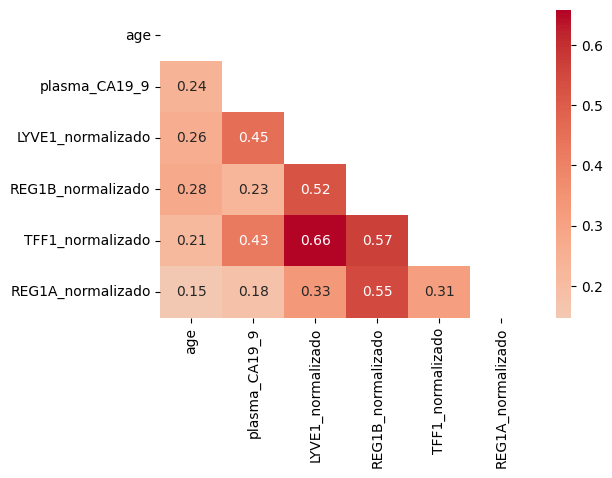

In [27]:
fig, ax = plt.subplots(figsize=(6, 4))
corr = datos[biomarcadores].corr(method="spearman")
sns.heatmap(corr, annot=True, fmt=".2", cmap="coolwarm", center=0, mask=np.triu(np.ones_like(corr, dtype=bool)), ax=ax)
plt.show()

- LYVE1_normalizado con TFF1_normalizado (r=0.66) y REG1B_normalizado con TFF1_normalizado (r=0.57) presentan los coeficientes más altos del panel, lo que indica cierta dependencia entre estos biomarcadores urinarios aunque no la suficiente para eliminarlos del estudio.
  
- LYVE1_normalizado con REG1B_normalizado (r=0.52) y REG1A_normalizado con REG1B_normalizado (r=0.55) presentan valores medios-altos pero no los suficientes para justificar su eliminación.

- REG1A_normalizado con TFF1_normalizado (r=0.31) presenta la correlación más baja entre biomarcadores urinarios, indicando que REG1A aporta información parcialmente independiente del resto del panel, aunque su interpretación sigue siendo limitada por el alto porcentaje de imputación.

- plasma_CA19_9 con biomarcadores urinarios (r=0.18 a 0.45) presenta coeficientes moderados, confirmando que el marcador tumoral CA19-9 y el panel urinario capturan información biológica complementaria e independiente. Destaca su correlación con LYVE1_normalizado (r=0.45), la más alta respecto al marcador sérico.
  
- La varaible age presenta las correlaciones más bajas con todos los biomarcadores (r=0.15 a 0.28), confirmando que la edad no está linealmente asociada con los niveles de ningún marcador de forma relevante.

La matriz de correlación indica que aunque los biomarcadores urinarios LYVE1, REG1B y TFF1 muestran correlaciones moderadas-altas entre sí, ningún par supera el umbral de r=0.8 que justificaría la eliminación de alguna variable. Las correlaciones moderadas-bajas entre plasma_CA19_9 y el panel urinario (r=0.18–0.45) validan que ambos capturan información biológica complementaria e independiente, reforzando la hipótesis del modelo combinado como estrategia diagnóstica.

### 3.5 CLUSTERING EN APRENDIZAJE NO SUPERVISADO

En el apartado anterior hemos evaluado cada biomarcador de forma individual identificando su capacidad discriminatoria, no obstante, en la práctica real el diagnóstico no se basa en un único marcador. Con el objetivo de explorar si el conjunto de biomarcadores presentan una estructura inherente que permita separar naturalmente los grupos diagnósticos, aplicamos técnicas de aprendizaje no supervisado previamente al modelado. Si los clusters (grupos de pacientes similares) encontrados coinciden con los grupos diagnósticos reales, implicaría que los biomarcadores contienen una señal discriminante intrínseca, más allá de lo que el análisis individual ya ha revelado. Si por el contrario los clusters no coinciden, esto justificaría el uso de modelos supervisados.

Aplicaremos dos algoritmos: K-Means (agrupa las muestras en k-clusters minimizando la distancia entre clusters) y clustering jerárquico (construye un árbol de similaridad sin especificar el número de grupos de antemano). La calidad del clustering se evalúa mediante el Coeficiente de Silueta (cohesión interna de los clusters) y el Índice de Rand Ajustado (similitud con  etiquetas diagnósticas reales).

In [28]:
biomarcadores

['age',
 'plasma_CA19_9',
 'LYVE1_normalizado',
 'REG1B_normalizado',
 'TFF1_normalizado',
 'REG1A_normalizado']

In [29]:
X_cluster = datos[biomarcadores].copy() #copia del dataset para clustering
X_sc = StandardScaler().fit_transform(X_cluster) #se hace escalado porque k-means utiliza distancias euclideas

y_real = datos["diagnosis"].values
etiquetas = {1: "Control", 2: "Benigno", 3: "PDAC"} #etiquetas reales

Utilizamos el Método del codo para determinar el número óptimo de clusters k. Este método entrena K-Means con distintos valores de k y calcula para cada uno la inercia, es decir, cuán compactos son los clusters: a mayor inercia, más dispersos los puntos dentro de cada grupo y más distintos los pacientes entre sí. Al representar la inercia frente a k obtenemos una curva que en algún punto (k óptimo) forma un codo, donde añadir un cluster más deja de mejorar significativamente la compacidad.

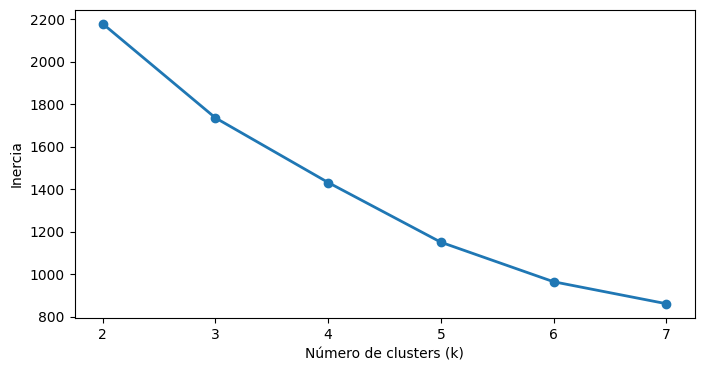

In [30]:
inercias = []
rango_k = range(2, 8)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_sc)
    inercias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(rango_k, inercias, marker="o", linewidth=2)
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.xticks(rango_k)
plt.show()

El resultado no muestra un punto de inflexión claro, lo que indica que los biomarcadores no generan una estructura de clusters naturalmente bien definida.

### 3.5.1 K-MEANS

Usamos k=3 porque coincide con los 3 grupos diagnósticos reales del dataset. Esto nos permite comparar los clusters encontrados con las etiquetas clínicas reales mediante el Índice de Rand Ajustado (ARI) y el Coeficiente de Silueta.

In [31]:
kmeans = KMeans(n_clusters=3, random_state=SEED, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_sc)

sil = silhouette_score(X_sc, clusters_kmeans) #calidad del cluster, cuanto más cercano a 1, cluster mejor separados

ari = adjusted_rand_score(y_real, clusters_kmeans) #similitud entre cluster y etiqueta, 1= coincidencia perfecta, 0= aleatoria

print(f"Coeficiente de Silueta: {sil:.3f}")
print(f"ARI: {ari:.3f}")

Coeficiente de Silueta: 0.619
ARI: 0.087


Coeficiente de Silueta: 0.619: implica que los clusters encontrados por K-Means tienen una cohesión razonable, los pacientes dentro de cada cluster se parecen entre sí en sus valores de biomarcadores. 
ARI: 0.087: muy cercano a 0, los clusters encontrados por K-Means casi no coinciden con los grupos diagnósticos reales. 

Con estos resultados podemos concluir que el algoritmo agrupa a los pacientes por similitud en sus biomarcadores, pero esa agrupación no refleja si tienen PDAC, enfermedad benigna o son controles sanos.

Dado que K-Means opera con 7 variables no es posible visualizar directamente los clusters. Para representarlos en un plano 2D aplicamos PCA (Análisis de Componentes Principales), que reduce las 7 dimensiones a 2 componentes principales. 

Varianza explicada — PC1: 43.4% | PC2: 15.7% | Total: 59.0%


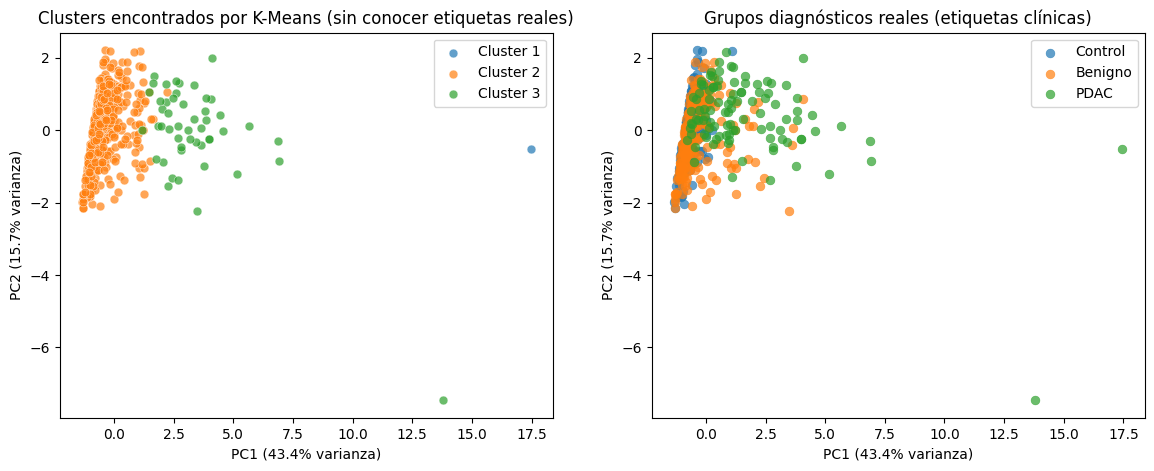

In [32]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_sc)
var_exp = pca.explained_variance_ratio_

print(f"Varianza explicada — PC1: {var_exp[0]:.1%} | PC2: {var_exp[1]:.1%} | Total: {sum(var_exp):.1%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#izquierda: clusters K-Means
for k in range(3):
    mask = clusters_kmeans == k
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Cluster {k+1}", alpha=0.7, s=40, edgecolors="white", linewidths=0.4)
    
axes[0].set_title("Clusters encontrados por K-Means (sin conocer etiquetas reales)")
axes[0].set_xlabel(f"PC1 ({var_exp[0]:.1%} varianza)")
axes[0].set_ylabel(f"PC2 ({var_exp[1]:.1%} varianza)")
axes[0].legend()

# Derecha: etiquetas diagnósticas reales
for label, nombre in etiquetas.items():
    mask = y_real == label
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   label=nombre,
                   alpha=0.7, s=40,linewidths=0.4)
axes[1].set_title("Grupos diagnósticos reales (etiquetas clínicas)")
axes[1].set_xlabel(f"PC1 ({var_exp[0]:.1%} varianza)")
axes[1].set_ylabel(f"PC2 ({var_exp[1]:.1%} varianza)")
axes[1].legend()
plt.show()

PCA reduce las 7 variables originales a 2 componentes. PC1 es la nueva variable que captura el 43.4% de la varianza total, mientras que PC2 captura información diferente a PC1 y añade un 15.7% adicional. Juntas suman el 59% de la información original, por lo que el 41% restante no se está representando en estos gráficos. El eje horizontal representa PC1 y el eje vertical representa PC2. Los pacientes situados más a la derecha tienen valores más altos en la combinación de biomarcadores que resume PC1, y los situados más arriba tienen valores más altos en la combinación que resume PC2.

Para el gráfico izquierdo:
- Cluster 1: pacientes con valores muy altos de biomarcadores.
- Cluster 2: pacientes con valores intermedios.
- Cluster 3: pacientes con valores bajos.

Para el gráfico:
- Control y Benigno son prácticamente iguales, aparecen solapados en el gráfico, por lo que sus valores de biomarcadores son muy similares.
- PDAC se despleza ligeramente hacia la derecha del eje PC1, hacia valores más altos de biomarcadores.

Si los biomarcadores tuvieran capacidad discriminante intrínseca, cada cluster de K-Means coincidirían con un grupo diagnóstico real. K-Means agrupa a los pacientes por la magnitud general de sus biomarcadores, pero esta no refleja el diagnóstico real.

### 3.5.2 DIAGNÓSTICO REAL

Para ver la distribución de pacientes en los cluesters:

Cluster K-Means,0,1,2
Diagnóstico real,,,
Benigno,0,196,12
Control,0,183,0
PDAC,1,64,37


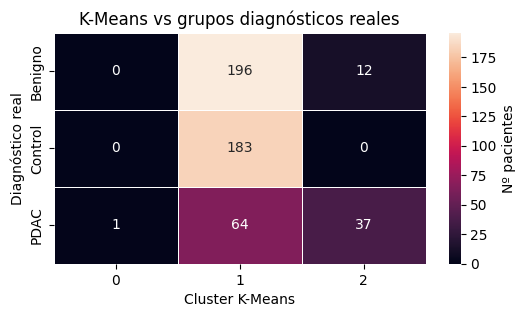

In [33]:
df_comp = pd.DataFrame({"Cluster_KMeans":    clusters_kmeans,
    "Diagnostico_real":  [etiquetas[y] for y in y_real]})

tabla_cruzada = pd.crosstab(df_comp["Diagnostico_real"],
    df_comp["Cluster_KMeans"],
    rownames=["Diagnóstico real"],
    colnames=["Cluster K-Means"])

display(tabla_cruzada)

plt.figure(figsize=(6, 3))
sns.heatmap(tabla_cruzada, annot=True, fmt="d", 
            linewidths=0.5, cbar_kws={"label": "Nº pacientes"})
plt.title("K-Means vs grupos diagnósticos reales")
plt.show()

El Cluster 0 está prácticamente vacío (solo 1 paciente) y el Cluster 2 contiene 37 pacientes PDAC con los biomarcadores más elevados, más 12 pacientes Benigno con valores altos, por lo que el algoritmo no ha sido capaz de separar PDAC del resto. Esto confirma que K-Means solo detecta los casos PDAC más extremos (los que tienen biomarcadores muy elevados) pero no es capaz de identificar los casos en estadios iniciales donde los biomarcadores aún no están suficientemente elevados para diferenciarse de los controles sanos. 


#### 3.5.3 Diagrama de árbol (Clustering Jerárquico)

El clustering jerárquico construye un árbol (dendrograma) que muestra cómo se van agrupando las muestras similares. La distancia en el eje vertical indica cuán diferentes son dos grupos en el momento de fusionarse. Una unión baja significa que los pacientes que se juntan son muy parecidos entre sí, mientras que una unión alta significa que los grupos que se fusionan son bastante diferentes.

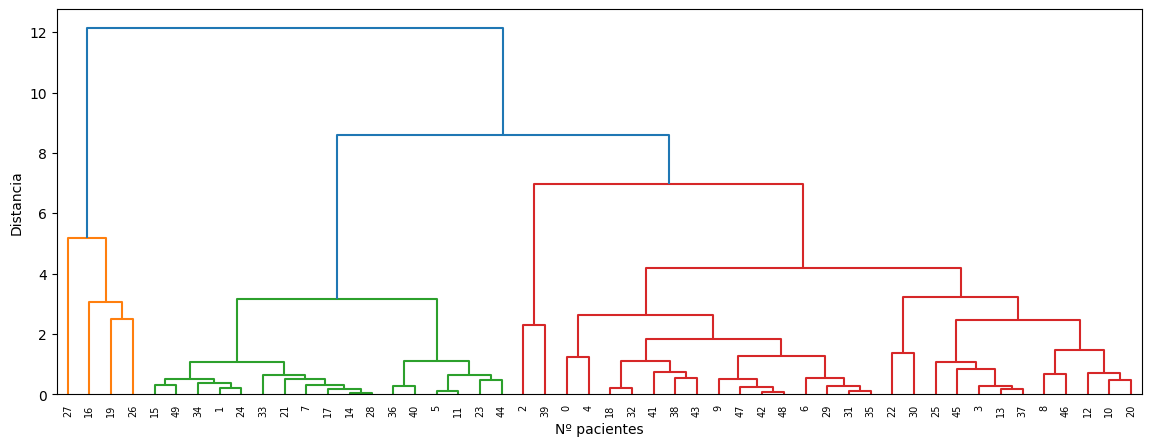

In [34]:
np.random.seed(SEED)
idx_muestra = np.random.choice(len(X_sc), size=50, replace=False)
X_muestra = X_sc[idx_muestra]
y_muestra = y_real[idx_muestra]

Z = linkage(X_muestra, method="ward")

plt.figure(figsize=(14, 5))
dendrogram(Z, leaf_rotation=90, leaf_font_size=7, color_threshold=0.7 * max(Z[:, 2]))
plt.xlabel("Nº pacientes")
plt.ylabel("Distancia")
plt.show()

- Cluster amarillo: grupo pequeño con fusión a distancia alta (5), se trata de pacientes con un perfil de biomarcadores diferente al resto. Probablemente corresponden a los casos PDAC con biomarcadores extremadamente elevados.

- Cluster verde: grupo medio que se fusiona a distancias bajas (máximo 3), pacientes similares entre sí. 

- Cluster rojo: mayoría de los pacientes. Se fusiona a distancias hasta 7, lo que indica mayor heterogeneidad interna. Probablemente mezcla Control, Benigno y PDAC de estadios iniciales con biomarcadores bajos.



### 3.6 CONCLUSIÓN
Como conclusión a este apartado, diremos que ningún biomarcador individual es capaz de discriminar de forma perfecta entre los tres grupos diagnósticos. LYVE1 destaca como el marcador más prometedor al presentar la mayor separación entre grupos, niveles consistentemente elevados en PDAC y una expresión homogénea dentro del grupo, aunque con riesgo de falsos positivos en controles sanos con niveles atípicamente elevados. REG1B y TFF1 aportan información complementaria pero con limitaciones: REG1B puede elevarse en condiciones inflamatorias benignas graves generando falsos positivos, y TFF1 produce falsos negativos en pacientes PDAC en estadios iniciales donde la expresión del marcador es todavía baja. El plasma_CA19_9, a pesar de ser el marcador tumoral de referencia clínica, muestra una utilidad limitada en estadios tempranos por su alta variabilidad intragrupo y baja especificidad en presencia de patologías benignas. REG1A presenta limitaciones metodológicas derivadas de su alto porcentaje de imputación que comprometen su interpretación clínica. La matriz de correlación confirma además que el panel no es redundante y que el marcador sérico y el panel urinario capturan información biológica complementaria e independiente.

El análisis de clustering no supervisado refuerza estas conclusiones. Al aplicar K-Means sobre el conjunto de biomarcadores sin conocer el diagnóstico de cada paciente, el Índice de Rand Ajustado obtenido (ARI=0.087) revela que los clusters encontrados apenas coinciden con los grupos diagnósticos reales. La tabla de correspondencia muestra que el algoritmo agrupa en un único cluster la práctica totalidad de los pacientes Control y Benigno junto con más de la mitad de los pacientes PDAC, siendo incapaz de separar los casos en estadios iniciales donde los biomarcadores aún no están suficientemente elevados. El clustering jerárquico confirma este mismo patrón, mostrando una división natural en 2 clusters en lugar de 3, donde solo los casos PDAC con biomarcadores extremadamente elevados forman un grupo diferenciado.

Con estos resultados queda validada la necesidad de combinar los diferentes biomarcadores mediante un modelo de aprendizaje automático, con el fin de compensar las limitaciones individuales de cada marcador, capturar patrones multivariantes no detectables de forma aislada y maximizar tanto la sensibilidad como la especificidad en la detección temprana del PDAC.

## 4. ENTRENAMIENTO DE MODELOS ML MEDIANTE APRENDIZAJE SUPERVISADO

Como se demostró en el apartado anterior, ningún biomarcador es capaz de discriminar individualmente entre los grupos de pacientes. Dado que las relaciones entre variables están sujetas a una alta variabilidad intragrupo, los modelos estadísticos clásicos no son suficientes para capturar la complejidad de estas interacciones.

Mediante el uso de técnicas de Machine Learning, podemos aplicar modelos que pueden aprender automaticamente patrones a partir del dataset, combinando información de todos los biomarcadores y ponderando su contribución según su relevancia diagnóstica. A diferencia de un análisis estadístico tradicional, los modelos de ML generalizan a nuevos pacientes no vistos durante el entrenamiento, por lo que los hace directamente aplicables en un contexto clínico real. Dado que el dataset dispone de etiquetas diagnósticas validas para cada muestra, se opta por técnicas de aprendizaje supervisado, concretamente algoritmos de clasificación binaria y multiclase, que permiten entrenar modelos a partir de ejemplos etiquetados y evaluar su capacidad de generalización sobre nuevos pacientes.

Nuestro modelo distinguirá entre los siguientes escenarios:

- E1: PDAC vs control sano
- E2: PDAC vs enfermedad benigna
- E3: PDAC vs no PDAC (control sano + enfermedad benigna)

Y se comparan tres estrategias diagnósticas tempranas:

- S1: CA19-9: marcador tumoral asociado a la presencia de ciertos cánceres del sistema digestivos, que también puede señalizar otro tipo de afecciones por lo que su resultado no es determinante para el diagnóstico del paciente.
- S2: Biomarcadores urinarios (LYVE1, REG1B, TFF1, REG1A): que podrían reflejas alteraciones relacionadas al PDAC.
- S3: Modelo combinado (CA-19-9 + biomarcadores urinarios).

Para cada combinación se entrena el mismo panel de modelos y se comparan los resultados, permitiendo cuantificar el valor añadido del panel urinario respecto al marcador estándar y del modelo combinado respecto a ambos.

Aunque la imputación se realizó previamente sobre datos para garantizar la coherencia en el análisis, en el entrenamiento utilizaremos datos_ml, una copia del dataset creada antes de dicha imputación. Esto permite que el pipeline aprenda la mediana exclusivamente a partir de los datos de entrenamiento (X_train) y la aplique posteriormente sobre el conjunto del test, evitando posible ruido.

In [35]:
datos_ml.info() #Valores nulos

<class 'pandas.core.frame.DataFrame'>
Index: 493 entries, 0 to 492
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                493 non-null    int64  
 1   sex                493 non-null    int64  
 2   diagnosis          493 non-null    int64  
 3   plasma_CA19_9      280 non-null    float64
 4   LYVE1_normalizado  493 non-null    float64
 5   REG1B_normalizado  493 non-null    float64
 6   TFF1_normalizado   493 non-null    float64
 7   REG1A_normalizado  236 non-null    float64
dtypes: float64(5), int64(3)
memory usage: 34.7 KB


Comenzamos planteando el problema como un problema de clasificación binaria: el paciente tiene PDAC o no tiene PDAC.

In [36]:
#Añadimos una nueva columna: si tiene PDAC=1, no tiene PDAC = 0
datos_ml["PDAC"] = (datos_ml["diagnosis"] == 3).astype(int)
datos_ml

,age,sex,diagnosis,plasma_CA19_9,LYVE1_normalizado,REG1B_normalizado,TFF1_normalizado,REG1A_normalizado,PDAC
0,33,0,1,11.7,0.487507,28.898735,357.098042,688.781915,0
1,81,0,1,NaN,2.094858,97.122355,215.376648,234.827175,0
2,51,1,1,7.0,0.186559,131.172875,590.910955,NaN,0
3,61,1,1,8.0,0.004000,86.390862,203.858989,NaN,0
4,62,1,1,9.0,0.004000,304.993252,191.204802,NaN,0
...,...,...,...,...,...,...,...,...,...
488,57,1,3,NaN,5.816622,428.455987,686.472149,NaN,1
489,82,1,3,NaN,12.963654,323.598801,567.516336,NaN,1
490,88,0,3,NaN,9.364070,103.087314,1145.516694,NaN,1
491,67,0,3,NaN,3.573710,375.834629,132.738803,NaN,1


In [37]:
datos_ml["PDAC"].value_counts() #102 pacientes con PDAC

PDAC
0    391
1    102
Name: count, dtype: int64

Se incluyen age y sex como variables demográficas estándar, aunque no aportan información relevante como hemos visto en el análisis previo más allá de la tendencia del PDAC a aparecer en edades avanzadas. Definimos las variables que van a ser utilizadas en el modelo:

In [38]:
variables_modelo = ["age","sex","plasma_CA19_9","LYVE1_normalizado","REG1B_normalizado","TFF1_normalizado","REG1A_normalizado"]

Dividimos el conjunto de datos entre prueba (test) y entrenamiento (train):

In [39]:
X = datos_ml[variables_modelo] #features: información del paciente a aprender, el modelo usa  las variables para predecir
y = datos_ml["PDAC"] #target: respuesta a predecir (0,1)

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
    test_size=0.20, #20% test, se usará en la evaluación final
    stratify=y,  #para mantener proporcionesde PDAC/sano del dataset de origen
    random_state=SEED #semilla aleatoria de pacientes, se suele usar el 42
)

Definimos los posibles escenarios y estrategias:

In [41]:
#{Nombre escenario: valor de "Diagnosis"}
ESCENARIOS = {"E1":[1, 3], #control sano y PDAC
    "E2":[2, 3], #enfermedad benigna y PDAC
    "E3": [1, 2, 3]} #todo tipo de paciente

#{nombre de estrategia diagnositica: marcadores/variables del dataset}
ESTRATEGIAS = {"S1":["age", "sex", "plasma_CA19_9"], # CA19_9 estandar
               "S2":["age", "sex", "LYVE1_normalizado", "REG1B_normalizado", "TFF1_normalizado", "REG1A_normalizado"], #biomarcadores
               "S3":["age", "sex", "plasma_CA19_9", "LYVE1_normalizado", "REG1B_normalizado", "TFF1_normalizado", "REG1A_normalizado"]} #CA19_9 + biomarcadores

Utilizaremos 7 modelos con mecanismos de aprendizaje distintos. Para cada combinación de escenario y estrategia, los 7 modelos evalúan sobre el mismo conjunto de entrenamiento y prueba, permitiendo identificar qué algoritmo se adapta mejor a cada contexto diagnóstico. 

- Regresión Logística: modelo lineal que estima la probabilidad de PDAC en función de los biomarcadores. Si modelos más complejos no superan significativamente a la regresión logística, indicaría que el problema es linealmente separable y no justifica complejidad adicional.
  
- Random Forest: construye múltiples árboles de decisión independientes sobre subconjuntos aleatorios de datos y features, y promedia sus predicciones. Se incluye por su robustez ante outliers extremos como los que presentan CA19-9 y TFF1, y porque maneja bien las relaciones no lineales entre biomarcadores.

- SVM (Support Vector Machine): busca el hiperplano que maximiza el margen de separación entre clases en un espacio de alta dimensión. Efectivo especialmente cuando las clases no son linealmente separables, como ocurre en PDAC vs Benigno donde los biomarcadores se solapan considerablemente.

- KNN (K-Nearest Neighbors): clasifica cada paciente según la clase mayoritaria de sus 7 vecinos más cercanos en el espacio de features. Su rendimiento indica si los grupos están bien separados en el espacio de biomarcadores.

- XGBoost: construye árboles secuencialmente donde cada uno corrige los errores del anterior, con regularización matemática para evitar generalizaciones sobre datos nuevos. Se incluye como modelo por su buen rendimiento en problemas de clasificación con datos tabulares clínicos, como en nuestro caso: un número moderado de muestras, variables numéricas continuas con distribuciones asimétricas y relaciones no lineales entre biomarcadores.

- Gradient Boosting: mismo principio que XGBoost pero con la implementación clásica de sklearn. Se incluye como alternativa para verificar si las diferencias de rendimiento entre implementaciones de boosting son relevantes en este dataset.

- AdaBoost: boosting adaptativo que en cada iteración aumenta el peso de los pacientes mal clasificados, obligando al siguiente árbol a enfocarse en los casos más difíciles. Es relevante para detectar los casos límite entre grupos, como a PDAC en estadios iniciales con biomarcadores bajos.

In [42]:
modelos_ML = {"Regresion": LogisticRegression(max_iter=1000, random_state=SEED),
    "RandomForest":RandomForestClassifier(n_estimators=300, random_state=SEED), #nº de árboles=300
    "SVM":SVC(probability=True, kernel="rbf", C=1.0, random_state=SEED), #para devolver probabilidades, capturar relaciones no lineales, regularizar máximos y mínimos
    "KNN":KNeighborsClassifier(n_neighbors=7), #nº de vecinos
    "XGBoost":XGBClassifier(n_estimators=300, max_depth=4,learning_rate=0.05, eval_metric="logloss",random_state=SEED, verbosity=0), #nº árboles, limite de la profundidad de 
              #cada árbol, cuanto corrige del árbol anterior, perdida de clasificacion binaria
    "GradientBoost": GradientBoostingClassifier(n_estimators=200, max_depth=3,learning_rate=0.05, random_state=SEED), #bajamos el nº de árboles por ser más complejo
    "AdaBoost":AdaBoostClassifier(n_estimators=200, random_state=SEED),}

Para determinar el modelo de diagnóstico más óptimo, usaremos el ROC-AUC (Area Under the Receiver Operating Characteristic Curve). Este es el área bajo la curva ROC, que representa gráficamente la relación entre la tasa de verdaderos positivos (sensibilidad) y la tasa de falsos positivos (especificidad) para todos los umbrales de decisión posibles. 

Este se calcula mediante verdaderos positivos (TP, pacientes con PDAC que el modelo clasifica correctamente) ,falsos positivos (FP, pacientes que el modelo clasifica erróneamente como PDAC), verdaderos negativos (TN, pacientes sanos que el modelo clasifica correctamente como no PDAC) Y falsos negativos (FN, pacientes con PDAC que el modelo clasifica erróneamente como sanos).

Un valor de 1 indica un clasificador perfecto que distingue todos los PDAC, mientras que 0.5 equivale a una clasificación aleatoria sin poder discriminativo, es por ello que consideraremos un valor de ROC-AUC=0.7 y un 0.5 de sensibilidad los mínimos para considerar un modelo útil. Es por ello que el modelo con mayor ROC-AUC en cada combinación se seleccionará como representante en la tabla comparativa final y determinando el modelo con mayor capacidad de priorizar correctamente los pacientes de mayor riesgo para pruebas diagnósticas. 

In [43]:
#definimos los contenedores globales donde se incluirán los resultados
todos_resultados = {}
todos_modelos = {}

#a partir de los datos de train y test, preprocesamos los datos, entrenamos los modelos y evalúamos
def entrenar_evaluar(X_train, X_test, y_train, y_test):
    
    # pipeline con imputación de valores nulos con mediana y estandariza las variables, exclusivamente en X_train para evitar data leakage
    pipeline = Pipeline([("imputer",SimpleImputer(strategy="median")), #imputación mediante mediana para sustituir valores nulos
        ("scaler",StandardScaler())]) #estandarización de cada variable a media=0 y desviación típica=1
    
    X_train_imp= pipeline.fit_transform(X_train)
    X_test_imp  = pipeline.transform(X_test)

    #Entrena cada modelo sobre X_train_imp y genera las probabilidades y la clase predicha sobre el test.
    resultados = {}
    modelos_entrenados = {}
    for i, modelo in modelos_ML.items():
        m = copy.deepcopy(modelo) #data limpia para cada iteracion (para que no afecten los resultados del modelo anterior)
        m.fit(X_train_imp, y_train) #entrenamiento del modelo sobre datos
        probabilidad = m.predict_proba(X_test_imp)[:, 1] 
        prediccion = m.predict(X_test_imp)

        #Evaluación: matriz de confusión para obtener los cuatro valores (TN, FP, FN, TP) y con ellos calcula las métricas
        tn, fp, fn, tp = confusion_matrix(y_test, prediccion).ravel()

        #redondeamos a 3 decimales
        resultados[i] = {"ROC-AUC": round(roc_auc_score(y_test, probabilidad), 3), #capacidad discriminatoria global
            "Bal.Accuracy":  round(balanced_accuracy_score(y_test, prediccion), 3), #penalizar fallos
            "Sensibilidad":  round(tp/(tp+fn) if (tp+fn)>0 else 0, 3), #detectar PDAC real
            "Especificidad": round(tn/(tn+fp) if (tn+fp)>0 else 0, 3), #dectar no PDAC correctamente
            "prob": probabilidad, #probabilidad de PDAC por paciente
            "pred": prediccion,} #clase predicha
       
        modelos_entrenados[i] = (m, X_train_imp, X_test_imp, pipeline)
 
    return resultados, modelos_entrenados

### 4.1 RESULTADOS DEL ENTRENAMIENTO

In [44]:
#Recorremos las combinaciones de escenarios y estrategias, y entrenamos y evaluamos los modelos.
for escenario, diagnosis in ESCENARIOS.items():
    subset = datos_ml[datos_ml["diagnosis"].isin(diagnosis)].copy() #seleccionamos pacientes según diagnosis y escenario

    for estrategia, features in ESTRATEGIAS.items():
        X = subset[features] #seleccionamos las columnas según la estrategia
        y = subset["PDAC"]

        X_tr, X_te, y_tr, y_te = train_test_split( #volvemos a definir train y test para cada subconjunto
            X, y, test_size=0.20, stratify=y, random_state=SEED)

        resultados, modelos_entrenados = entrenar_evaluar(X_tr, X_te, y_tr, y_te) #función de entrenamiento y evaluación

        todos_resultados[escenario, estrategia] = resultados
        todos_modelos[escenario, estrategia] = (modelos_entrenados, X_tr, X_te, y_tr, y_te, features)
        
        mejor_modelo = max(resultados, key=lambda n: resultados[n]["ROC-AUC"]) #modelo con mayor ROC-AUC=modelo óptimo para diagnósticos tempranos
        print(escenario, estrategia, "Mejor modelo: ", mejor_modelo, "ROC-AUC:", round(resultados[mejor_modelo]["ROC-AUC"], 3), "Sens:", round(resultados[mejor_modelo]["Sensibilidad"], 3))

E1 S1 Mejor modelo:  GradientBoost ROC-AUC: 0.897 Sens: 0.75
E1 S2 Mejor modelo:  GradientBoost ROC-AUC: 0.957 Sens: 0.75
E1 S3 Mejor modelo:  XGBoost ROC-AUC: 0.973 Sens: 0.85
E2 S1 Mejor modelo:  AdaBoost ROC-AUC: 0.85 Sens: 0.65
E2 S2 Mejor modelo:  GradientBoost ROC-AUC: 0.846 Sens: 0.75
E2 S3 Mejor modelo:  RandomForest ROC-AUC: 0.909 Sens: 0.85
E3 S1 Mejor modelo:  AdaBoost ROC-AUC: 0.905 Sens: 0.7
E3 S2 Mejor modelo:  AdaBoost ROC-AUC: 0.909 Sens: 0.6
E3 S3 Mejor modelo:  XGBoost ROC-AUC: 0.941 Sens: 0.8


Generamos una tabla global con los modelos que dan mejores resultados de cada combinación:

In [45]:
filas_global = []
for (esc, est), resultados in todos_resultados.items():
    mejor = max(resultados, key=lambda n: resultados[n]["ROC-AUC"])
    m = resultados[mejor]
    filas_global.append({
        "Escenario":     esc,
        "Estrategia":    est,
        "Mejor modelo":  mejor,
        "ROC-AUC":       m["ROC-AUC"], #capacidad discriminativa global del modelo
        "Bal.Accuracy":  m["Bal.Accuracy"], #media entre sensibilidad y especificidad, mide el rendimiento global del modelo penalizando los errores 
        "Sensibilidad":  m["Sensibilidad"], #fracción de pacientes PDAC correctamente detectados
        "Especificidad": m["Especificidad"],}) #fracción de pacientes no-PDAC correctamente descartados
 
tabla_global = pd.DataFrame(filas_global).set_index(["Escenario", "Estrategia"])
display(tabla_global)

Mejor modelo  ROC-AUC  Bal.Accuracy  Sensibilidad  \
Escenario Estrategia                                                       
E1        S1          GradientBoost    0.897         0.834          0.75   
          S2          GradientBoost    0.957         0.848          0.75   
          S3                XGBoost    0.973         0.911          0.85   
E2        S1               AdaBoost    0.850         0.765          0.65   
          S2          GradientBoost    0.846         0.780          0.75   
          S3           RandomForest    0.909         0.865          0.85   
E3        S1               AdaBoost    0.905         0.831          0.70   
          S2               AdaBoost    0.909         0.756          0.60   
          S3                XGBoost    0.941         0.875          0.80   

                      Especificidad  
Escenario Estrategia                 
E1        S1                  0.919  
          S2                  0.946  
          S3                  0.973  
E2        S1                  0.881  
          S2                  0.810  
          S3                  0.881  
E3        S1                  0.962  
          S2                  0.911  
          S3                  0.949

Desde el punto de vista clínico, el modelo E1-S3 con XGBoost presenta el mejor equilibrio entre sensibilidad (0.85) y especificidad (0.973), detectando 17 de los 20 casos PDAC del test sin generar apenas falsos positivos. Los 3 casos no detectados corresponden previsiblemente a pacientes en estadios muy iniciales con biomarcadores bajos, que constituyen el principal reto diagnóstico del panel y justifican el análisis por umbral realizado en el siguiente apartado.

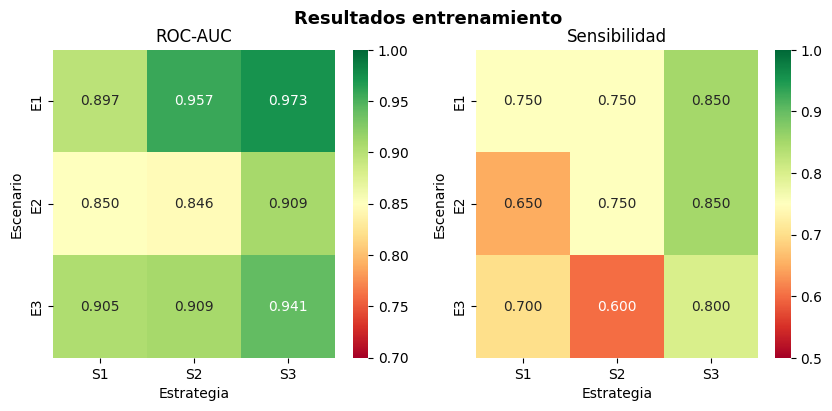

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Resultados entrenamiento", fontsize=13, fontweight="bold")

for ax, metrica, vmin in zip(axes, ["ROC-AUC", "Sensibilidad"], [0.7, 0.5]):
    pivot = tabla_global.pivot_table(values=metrica, index="Escenario", columns="Estrategia")
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn",vmin=vmin, vmax=1.0, ax=ax)
    ax.set_title(metrica)

plt.show()

A partir de estos gráficos podemos concluir:

Para ROC-AUC:
- El modelo combinado S3 obtiene el mejor rendimiento en los tres escenarios, lo que confirma que la combinación de CA19-9 con los biomarcadores urinarios supera al individual.
  
- El mejor resultado es para E1-S3 (ROC-AUC=0.973), que corresponde al escenario PDAC vs Control sano con el modelo combinado.

- E2 (PDAC vs Benigno) es el escenario más difícil en todas las estrategias, con valores de 0.850, 0.846 y 0.909, esto es coherente dado que ciertas condiciones benignas pueden elevar los biomarcadores hasta niveles compatibles con PDAC, dificultando la discriminación.

- Comparando estrategias, S2 (biomarcadores urinarios) supera a S1 (CA19-9) en E1 (0.957 vs 0.897) y E3 (0.909 vs 0.905), pero no en E2 (0.846 vs 0.850) donde CA19-9 resulta ligeramente más útil para distinguir PDAC de patologías benignas.

Para sensibilidad:
- E1-S3 y E2-S3 comparten el mejor valor de sensibilidad (0.850), lo que indica que el modelo combinado maximiza la detección de PDAC independientemente del grupo de comparación.
  
- El valor más preocupante es E3-S2 (0.600), donde el panel urinario solo detecta el 60% de los casos PDAC cuando compite contra todos los tipos de pacientes, lo que refuerza la necesidad del modelo combinado en el escenario clínico más realista.

- S1 (solo CA19-9) muestra sensibilidades de 0.750, 0.650 y 0.700, confirmando su limitación en estadios iniciales donde muchos pacientes PDAC tienen niveles de CA19-9 dentro del rango normal.

Estos resultados validan la hipótesi que planteabamos al inicio de este notebook: con la combinación de biomarcadores urinarios y CA19-9 se obtienen los mejores resultados para el diagnóstico del PDAC en todos los escenarios, y el escenario PDAC vs Benigno es el más difícil de resolver, con los valores más bajos tanto de ROC-AUC como de sensibilidad.

### 4.2 ANÁLISIS DETALLADO DEL MEJOR RESULTADO: E1-S3 XGBoost

### 4.2.1 REPORTE DE CLASIFICACIÓN

In [47]:
mejor_ROC_AUC = max(todos_resultados, key=lambda k: max(v["ROC-AUC"] for v in todos_resultados[k].values())) #obtenemos la mejor combinación (escenario, estrategia) 
mejor_modelo = max(todos_resultados[mejor_ROC_AUC], key=lambda n: todos_resultados[mejor_ROC_AUC][n]["ROC-AUC"]) #obtenemos el modelo con mayor ROC-AUC
 
modelos_entrenados, X_tr, X_te, y_tr, y_te, features = todos_modelos[mejor_ROC_AUC] #recupera datos y modelos ya entrenados de la mejor combinación
modelo_final, X_train_imp, X_test_imp, pipeline = modelos_entrenados[mejor_modelo]

#probabilidades y predicciones del mejor modelo
prob_final = modelo_final.predict_proba(X_test_imp)[:, 1]
pred_final = modelo_final.predict(X_test_imp)
 
print("Mejor combinación:", mejor_ROC_AUC)
print("Mejor modelo:", mejor_modelo)
print(classification_report(y_te, pred_final, target_names=["NO-PDAC", "PDAC"]))
 

Mejor combinación: ('E1', 'S3')
Mejor modelo: XGBoost
              precision    recall  f1-score   support

     NO-PDAC       0.92      0.97      0.95        37
        PDAC       0.94      0.85      0.89        20

    accuracy                           0.93        57
   macro avg       0.93      0.91      0.92        57
weighted avg       0.93      0.93      0.93        57



Precision (de todos los pacientes que el modelo clasifica como pertenecientes a una clase, qué fracción realmente lo son):

- NO-PDAC (0.92): de los pacientes clasificados como sanos, el 92% realmente lo son, el resto son PDAC clasificados erróneamente como sanos (falsos negativos).
  
- PDAC (0.94): de los pacientes clasificados como PDAC, el 94% realmente tienen la enfermedad, solo el 6% son sanos clasificados erróneamente como PDAC (falsos positivos).

Recall (sensibilidad, de todos los pacientes que realmente pertenecen a una clase, qué fracción detecta el modelo correctamente):

- NO-PDAC (0.97): el modelo identifica correctamente el 97% de los sanos reales, Solo 1 paciente sano es clasificado erróneamente como PDAC.
  
- PDAC (0.85): el modelo detecta el 85% de los PDAC reales. 3 pacientes con PDAC no son detectados, lo que constituye el principal riesgo clínico del modelo.

F1-score (media entre precision y recall):

- NO-PDAC (0.95): rendimiento muy alto para la clase mayoritaria.
  
- PDAC (0.89): algo inferior por los 3 falsos negativos.

Support (número de pacientes reales de cada clase en el test): 37 no-PDAC y 20 PDAC.

Accuracy (0.93): el modelo clasifica correctamente 53 de los 57 pacientes del test. Los 4 errores se atribuyen a 1 falso positivo (sano clasificado como PDAC) y 3 falsos negativos (PDAC no detectados).

Macro avg: media simple de las métricas de ambas clases sin tener en cuenta el tamaño de cada una. El valor de 0.91 en recall indica que el modelo tiene un rendimiento equilibrado entre clases.

Weighted avg: media ponderada por el número de pacientes de cada clase. El valor de 0.93 confirma que el modelo es robusto y no está sesgado hacia la clase mayoritaria.

### 4.2.2 MATRIZ DE CONFUSIÓN

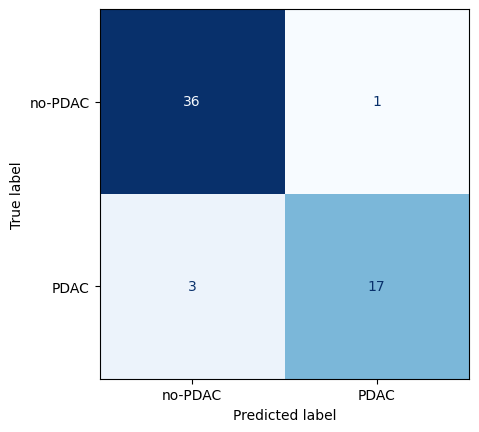

In [48]:
ConfusionMatrixDisplay.from_predictions(y_te, pred_final, display_labels=["no-PDAC", "PDAC"], colorbar=False, cmap="Blues")
plt.show() 

La matriz de confusión muestra 57 pacientes del test distribuidos en 4 categorías:

- 36 (TN): pacientes sanos que el modelo clasifica correctamente como NO-PDAC. De los 37 controles sanos del test, 36 son identificados correctamente.
  
- 1 (FP): paciente sano clasificado erróneamente como PDAC. Clínicamente implica una derivación innecesaria a pruebas diagnósticas adicionales, lo que genera coste temporal y económico.

- 3 (FN): pacientes con PDAC clasificados erróneamente como sanos. Son el error clínicamente más grave ya que estos 3 pacientes no recibirían tratamiento a tiempo, se corresponden probablemente a casos en estadios muy iniciales donde los biomarcadores aún no están suficientemente elevados para que el modelo los detecte.

- 17 (TP): pacientes con PDAC correctamente detectados. De los 20 casos PDAC del test, el modelo identifica 17 correctamente.

### 4.2.3 CURVAS ROC Y PRECISION-RECALL

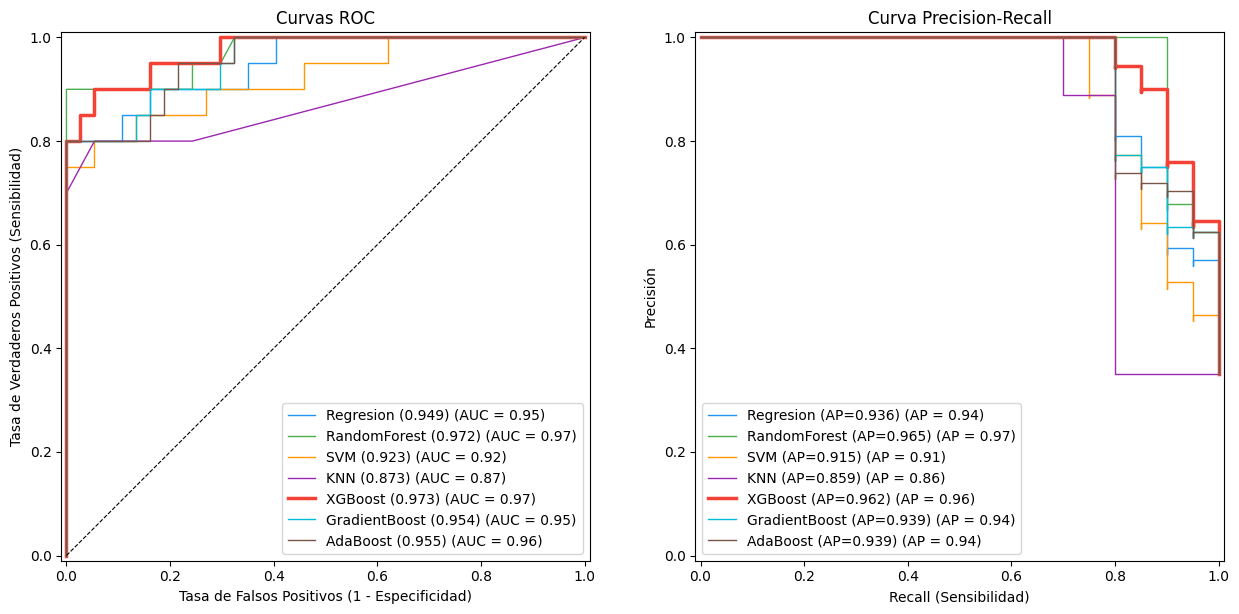

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Colores por modelo
colores = {
    "Regresion":    "#2196F3",  # azul
    "RandomForest": "#4CAF50",  # verde
    "SVM":          "#FF9800",  # naranja
    "KNN":          "#9C27B0",  # morado
    "GradientBoost":"#00BCD4",  # celeste
    "AdaBoost":     "#795548",  # marrón
    "XGBoost":      "#F44336",  # rojo
}

# Curvas ROC de los 7 modelos
for i in modelos_ML:
    m, _, X_te_proc, _ = modelos_entrenados[i] #recupera modelo entrenado y datos del test
    p = m.predict_proba(X_te_proc)[:, 1]  #probabilidad de PDAC=1 
    RocCurveDisplay.from_predictions(y_te, p, ax=axes[0],name=f"{i} ({roc_auc_score(y_te, p):.3f})",color=colores[i],linewidth=2.5 if i == mejor_modelo else 1) #resaltamos el mejor modelo
    
axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8) #clasificador aleatorio(AUC=0.5)
axes[0].set_title("Curvas ROC")
axes[0].set_xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
axes[0].set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")

# Curva Precision-Recall de los 7 modelos
for i in modelos_ML:
    m, _, X_te_proc, _ = modelos_entrenados[i]
    p = m.predict_proba(X_te_proc)[:, 1]
    PrecisionRecallDisplay.from_predictions(y_te, p, ax=axes[1],name=f"{i} (AP={average_precision_score(y_te, p):.3f})",color=colores[i],linewidth=2.5 if i == mejor_modelo else 1)
    
axes[1].set_title("Curva Precision-Recall")
axes[1].set_xlabel("Recall (Sensibilidad)")
axes[1].set_ylabel("Precisión")

plt.show()

Curvas ROC:

- Todos los modelos superan la diagonal de referencia, lo que confirma que ninguno se comporta como un clasificador aleatorio. XGBoost (rojo, AUC=0.973) y RandomForest (verde, AUC=0.972) tienen los mayores valores, seguidos de AdaBoost (0.955), GradientBoost (0.954) y Regresión Logística (0.949). SVM (0.923) y KNN (0.873), siendo KNN el único modelo que se acerca a la diagonal.

Curva Precision-Recall:

- RandomForest (verde, AP=0.965) supera ligeramente a XGBoost (rojo, AP=0.962). Ambos mantienen una precisión cerca de 1.0 hasta un recall de aproximadamente 0.85, punto donde la curva cae indicando que detectar los casos PDAC restantes. KNN (AP=0.859) es el modelo con peor rendimiento, con una caída más pronunciada y temprana. La Regresión Logística (AP=0.936) muestra un comportamiento sorprendentemente bueno dado su simplicidad, lo que refuerza que el problema tiene una componente lineal relevante.

### 4.3 ANÁLISIS POR UMBRAL DE DECISIÓN
En la detección clínica el coste de un falso negativo (PDAC no detectado) es mayor que el de un falso positivo (pruebas adicionales innecesarias), lo que justifica priorizar la sensibilidad sobre la especificidad. Cálculamos el umbral ante clases asimétricas mediante: 

umbral_óptimo = coste_FP / (coste_FP + coste_FN)

En clasificación binaria el umbral 0.5 es óptimo solo cuando el coste de ambos errores es igual, si el del falso negativo es mayor, el denominador crece y el umbral se reduce por debajo de 0.5. En la práctica clínica habitual se usa el modelo como herramienta de cribado con umbral bajo para maximizar la sensibilidad, y reservar las pruebas más invasivas y costosas para los casos positivos. Este enfoque en dos etapas (cribado + confirmación) es el estándar en programas de detección temprana de cáncer como el cribado de cáncer colorrectal o de mama.

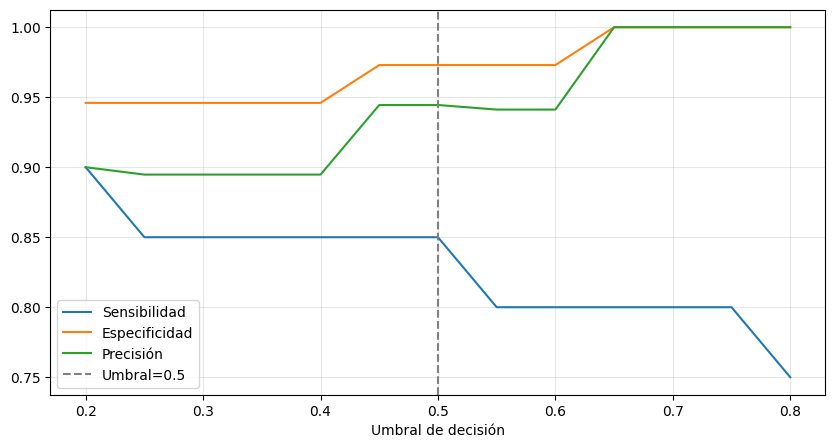

In [50]:
umbrales = np.arange(0.2, 0.85, 0.05) #umbrales a evaluar
sensibilidad, especificidad, precision = [], [], []
 
for i in umbrales:
    yp = (prob_final >= i).astype(int) #si la probabilidad de PDAC supera i, es PDAC
    tn, fp, fn, tp = confusion_matrix(y_te, yp).ravel() #sacamos matriz de confusion
    sensibilidad.append(tp/(tp+fn) if (tp+fn)>0 else 0)
    especificidad.append(tn/(tn+fp) if (tn+fp)>0 else 0)
    precision.append(tp/(tp+fp) if (tp+fp)>0 else 0)
 
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(umbrales, sensibilidad, label="Sensibilidad")
ax.plot(umbrales, especificidad, label="Especificidad")
ax.plot(umbrales, precision, label="Precisión")
ax.axvline(0.5, color="gray", linestyle="--", label="Umbral=0.5")
ax.set_xlabel("Umbral de decisión")

ax.legend()
ax.grid(alpha=0.3)
plt.show()

- Sensibilidad: en 0.90 para umbrales bajos (0.2) y cae progresivamente hasta 0.75, lo que implica que en umbrales por debajo de 0.3 el modelo detecta 1 caso PDAC adicional respecto al umbral por defecto, pasando de 17 a 18 de los 20 casos reales.

- Especificidad: estable en 0.95 para umbrales bajos, sube a 0.97 en el umbral 0.5 y alcanza 1.0 a partir de 0.65. Concluimos que aumentar la especificidad reduce la sensibilidad y viceversa.

- Precisión: es estable entre 0.90 y 0.95, con caída en umbrales muy bajos (más falsos positivos) y un salto a 1.0 en umbrales altos (solo clasifica como PDAC los casos con probabilidad muy alta).

El valor más óptimo es el umbral 0.2–0.3, donde la sensibilidad sube a 0.90 detectando 18 de 20 casos PDAC, con una especificidad de 0.95 y una precisión de 0.90. Esto añade 2 falsos positivos respecto al umbral 0.5, lo que está justificado dado que nos permite detectar un PDAC más. Por defecto, el valor de umbral a 0.5 sigue siendo el más equilibrado, pero desde el punto de vista clínico reducirlo a 0.3 mejoraría la detección temprana sin comprometer significativamente la especificidad.

In [51]:
print("Umbral   Sensibilidad   Especificidad   Precisión   FN   FP")

for i in [0.2,0.5,0.7]:
    yp = (prob_final >= i).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, yp).ravel()
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    print(i, "       ", round(sens,3), "        ", round(spec,3),"         ", round(prec,3), "      ", fn, "  ", fp)

Umbral   Sensibilidad   Especificidad   Precisión   FN   FP
0.2         0.9          0.946           0.9        2    2
0.5         0.85          0.973           0.944        3    1
0.7         0.8          1.0           1.0        4    0


- Umbral=0.2: es el umbral con mayor sensibilidad, lo que puede ser preferible ya que minimiza los casos PDAC no detectados. Los 2 falsos positivos suponen derivar a 2 pacientes sanos a pruebas adicionales, un coste asumible clínicamente.
  
- Umbral 0.5: detecta 17 de 20 casos PDAC con 1 falso positivo. Presenta el mejor equilibrio entre sensibilidad y especificidad, con una precisión del 94.4% que indica que prácticamente todos los pacientes clasificados como PDAC realmente lo tienen.

- Umbral 0.7: especificidad y precisión perfectas (1.0), es decir cero falsos positivos, pero la sensibilidad cae a 0.80 perdiendo 4 casos PDAC reales.

La elección del umbral óptimo dependerá del contexto de aplicación. En un programa de cribado poblacional donde el objetivo es no perder ningún caso PDAC, el umbral 0.2 sería preferible al detectar un caso adicional a costa de una derivación extra. En un contexto clínico donde se busca el mayor equilibrio entre detección y especificidad, el umbral por defecto de 0.5 es la opción más adecuada. 

## 5. INTERPRETABILIDAD CLÍNICA 

### 5.1 SHAP

En el ámbito clínico es necesario explicar por qué el modelo clasifica a un paciente como PDAC para que sea útil y aceptado por los profesionales sanitarios. En este contexto utilizamos SHAP, una librería para la interpretabilidad de modelos de Machine Learning. Esta se basa en la teoría de juegos cooperativos, que resuelve el problema de distribuir equitativamente el mérito entre varios jugadores que colaboran para obtener resultados. Adaptándolo a ML, dado un conjunto de variables de una predicción calcula cuánto contribuye cada variable al resultado final de forma justa. 

Para cada paciente y variable calcula un valor que indica cuánto contribuye esa variable a desplazar la predicción desde el valor medio del modelo hacia la predicción concreta de ese paciente. Lo hace evaluando todas las combinaciones posibles de variables con y sin cada biomarcador, promediando el efecto marginal de incluirla. Matemáticamente garantiza que la suma de todos los valores SHAP de un paciente más el valor base del modelo es igual a la predicción final de ese paciente.

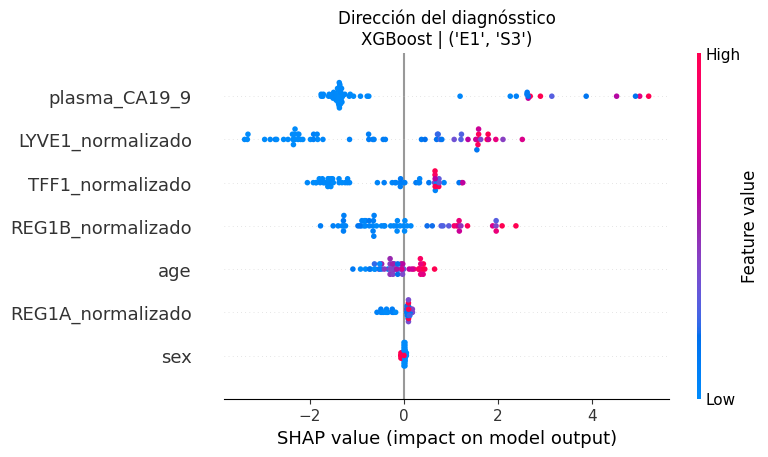

In [52]:
explainer   = shap.TreeExplainer(modelo_final) #análisis de estructura del modelo
shap_values = explainer.shap_values(X_test_imp) #valores SHAP de todos los pacientes (matriz paciente x variable)
 
# Compatibilidad de versiones 
if isinstance(shap_values, list):
    sv = shap_values[1]
elif hasattr(shap_values, "values"):
    sv = shap_values.values
    if sv.ndim == 3: sv = sv[:, :, 1]
else:
    sv = shap_values
    if sv.ndim == 3: sv = sv[:, :, 1]

#cada punto es un paciente, el color indica el valor de la variable y la posición si empuja la predicción hacia PDAC (derecha) o hacia no-PDAC (izquierda)
plt.figure(figsize=(9, 5))
shap.summary_plot(sv, X_test_imp, feature_names=features, show=False)
plt.title(f"Dirección del diagnósstico\n{mejor_modelo} | {mejor_ROC_AUC}")
plt.show()

- CA19-9: los puntos rosas (valores altos de CA19-9) se concentran en la derecha confirmando que los niveles elevados empujan la predicción hacia PDAC, y los puntos azules (valores bajos) se concentran en la izquierda empujando hacia no-PDAC.

- LYVE1_normalizado: similar al CA19-9 con valores altos empujan hacia PDAC y bajos hacia NO-PDAC.

- TFF1_normalizado: mismo patrón pero con menor separación entre puntos altos y bajos.

- REG1B_normalizado: efecto más concentrado y menor dispersión, indicando un comportamiento más homogéneo entre pacientes.

- age: los puntos están concentrados cerca del cero, confirmando que la edad tiene escaso impacto en la predicción individual aunque aporta algo de información.

- REG1A_normalizado: contribución muy baja y puntos cercanos a cero.

- sex:  contribución prácticamente nula.

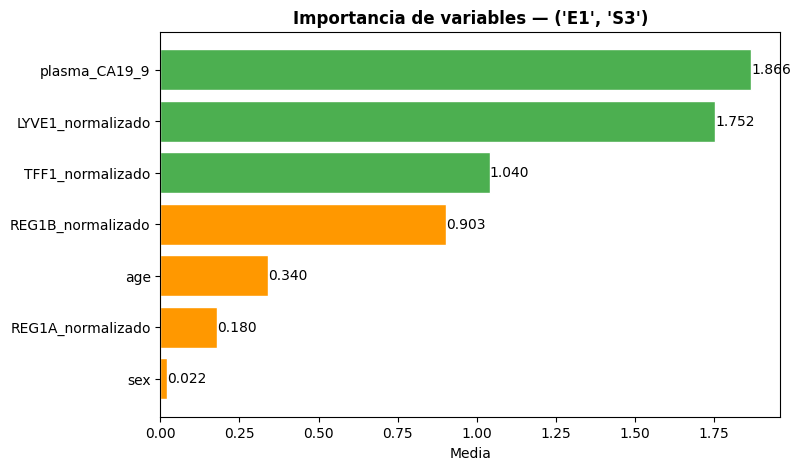

Ranking de importancia:
      Biomarcador    Media
    plasma_CA19_9 1.865736
LYVE1_normalizado 1.751559
 TFF1_normalizado 1.040308
REG1B_normalizado 0.903372
              age 0.340195
REG1A_normalizado 0.179879
              sex 0.021848


In [53]:
#Ranking de importancia media
mean_shap = np.abs(sv).mean(axis=0) #importancia media de cada variable
shap_df   = pd.DataFrame({"Biomarcador": features, "Media": mean_shap})
shap_df   = shap_df.sort_values("Media", ascending=True)
 
fig, ax = plt.subplots(figsize=(8, 5))
colores_shap = ["#4CAF50" if v > shap_df["Media"].median() else "#FF9800" for v in shap_df["Media"]]
bars = ax.barh(shap_df["Biomarcador"], shap_df["Media"], color=colores_shap, edgecolor="white")
for bar, val in zip(bars, shap_df["Media"]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center")

ax.set_xlabel("Media")
ax.set_title(f"Importancia de variables — {mejor_ROC_AUC}", fontweight="bold")
plt.show()
 
print("Ranking de importancia:")
print(shap_df.sort_values("Media", ascending=False).to_string(index=False))
 

El ranking confirma la jerarquía observada en el diagrama de puntos:

- CA19-9 (1.866) y LYVE1_normalizado (1.752) son los biomarcadores más importantes y están muy por encima del resto.
  
- TFF1_normalizado (1.040) y REG1B_normalizado (0.903) forman un segundo grupo con importancia moderada.

- age (0.340), REG1A_normalizado (0.180) y sex (0.022) tienen una contribución marginal.

Los resultados son coherentes con el apartado 3. El modelo ha aprendido los patrones correctos, los biomarcadores con mayor separación visual entre grupos en los histogramas y boxplots (plasma_CA19_9 y LYVE1) son también los que más contribuyen a las predicciones individuales. 

### 5.2 DALEX

DALEX es una librería que mide la importancia de cada variable evaluando cuánto empeora el modelo cuando se elimina su información permutando aleatoriamente sus valores. 

In [54]:
explainer = dx.Explainer(modelo_final,           # modelo entrenado
    pd.DataFrame(X_test_imp, columns=features),  # datos de test con nombres de columnas
    y_te,                   # etiquetas 
    label="XGBoost E1-S3")


# cuanto empeora el ROC-AUC al permutar cada variable aleatoriamente.
importancia = explainer.model_parts(loss_function="1-auc")
importancia.plot()

Preparation of a new explainer is initiated

  -> data              : 57 rows 7 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 57 values
  -> model_class       : xgboost.sklearn.XGBClassifier (default)
  -> label             : XGBoost E1-S3
  -> predict function  : <function yhat_proba_default at 0x7d2f2685c400> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.000853, mean = 0.315, max = 0.998
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.611, mean = 0.036, max = 0.989
  -> model_info        : package xgboost

A new explainer has been created!


Este gráfico muestra la importancia de las variables para el modelo, es decir, cuánto cae el ROC-AUC al permutar aleatoriamente cada variable, por lo que una caída mayor indicaría que el modelo depende más de esa variable. En nuestro caso, el CA19_9 (+0.1) es la variable más crítica ya que sin su información el ROC-AUC cae 12.2 puntos porcentuales. LYVE1_normalizado (+0.057) sería la segunda variable más importante con una caída considerable. 

In [55]:

# como varía la predicción media del modelo al cambiar el valor manteniendo el resto constante
perfil = explainer.model_profile(variables=features)
perfil.plot()

Calculating ceteris paribus: 100%|██████████| 7/7 [00:00<00:00, 80.31it/s]


En estos gráficos se puede observar cómo varía la probabilidad media de PDAC al cambiar el valor de cada biomarcador manteniendo el resto constante.

- CA19_9: sube bruscamente hasta log≈0 donde alcanza 0.80 y se estabiliza completamente. El modelo aprende un umbral muy claro: cualquier valor por encima de ese punto dispara la probabilidad de PDAC al máximo.
  
- LYVE1_normalizado: sube de forma gradual entre log=-1 y log=0.5, pasando de 0.22 a 0.50, lo que indica que este discrimina mejor en rangos intermedios sin un umbral de corte tan definido como CA19-9.

- REG1B_normalizado y TFF1_normalizado: subida rápida en valores bajos y estabilización en torno a 0.47-0.48.

- REG1A_normalizado: curva completamente plana en torno a 0.30 para todo el rango de valores. El modelo no aprende ninguna relación útil con esta variable, confirmando el artefacto de imputación que domina su distribución.

- age y sex: curvas prácticamente planas sin apenas variación, confirmando su irrelevancia diagnóstica en este modelo.

In [56]:
# Paciente clasificado como PDAC con mayor probabilidad
idx_pdac = prob_final.argmax()
paciente_pdac = pd.DataFrame(X_test_imp[idx_pdac:idx_pdac+1], columns=features)
exp_pdac = explainer.predict_parts(paciente_pdac, type="break_down")
exp_pdac.plot(title=f"Explicación local — paciente PDAC (prob={prob_final[idx_pdac]:.3f})")

El gráfico descompone cómo cada variable desplaza la predicción desde el valor base del modelo (intercept=0.315) hasta la predicción final (0.998).

- CA19_9=0.677 (+0.501): empuja la predicción 0.501 puntos hacia PDAC, siendo responsable de más de la mitad del desplazamiento total desde el valor base hasta la predicción final.

- LYVE1_normalizado=1.791: termina de llevar la predicción hasta prácticamente 1.0. El resto de variables (REG1B, TFF1, age, REG1A, sex) tienen contribuciones positivas pero marginales.

In [57]:
# Paciente clasificado como NO-PDAC con mayor certeza
idx_nopdac = prob_final.argmin()
paciente_nopdac = pd.DataFrame(X_test_imp[idx_nopdac:idx_nopdac+1], columns=features)
exp_nopdac = explainer.predict_parts(paciente_nopdac, type="break_down")
exp_nopdac.plot(title=f"Explicación local — paciente no-PDAC (prob={prob_final[idx_nopdac]:.3f})")

- LYVE1_normalizado=-0.612 (-0.029): primera contribución negativa que empieza a alejar la predicción del PDAC.

- CA19_9=-0.163 (-0.218): reduce la predicción 0.218 puntos, siendo el factor más determinante para descartar el PDAC.

- REG1B_normalizado=-0.404 (-0.062) y TFF1_normalizado=-0.528 (-0.027): contribuciones negativas adicionales que confirman niveles bajos en todos los biomarcadores urinarios.

- REG1A_normalizado (+0.011), age (+0.009) y sex (+0.001): pequeñas contribuciones positivas que no compensan el efecto negativo de los biomarcadores principales.

Los análisis de DALEX y SHAP apuntan a las mismas conclusiones: plasma_CA19_9 y LYVE1 son los biomarcadores más determinantes, REG1B y TFF1 aportan información complementaria, y REG1A, age y sex tienen una contribución prácticamente nula.

# Obtención del dataset

 [1] Debernardi, S., O’Brien, H., Algahmdi, A. S., Malats, N., Stewart, G. D., Plješa-Ercegovac, M., Costello, E., Greenhalf, W., Saad, A., Roberts, R., Ney, A., Pereira, S. P., Kocher, H. M., Duffy, S., Blyuss, O., & Crnogorac-Jurcevic, T. (2020). A combination of urinary biomarker panel and PancRISK score for earlier detection of pancreatic cancer: A case–control study. PLoS Medicine, 17(12), e1003489. https://doi.org/10.1371/journal.pmed.1003489